# Bank Transaction Fraud Detection

Dieses Notebook dokumentiert den gesamten Machine Learning-Workflow zur Betrugserkennung bei Banktransaktionen, bestehend aus explorativer Datenanalyse, Vorverarbeitung, Modelltraining und erklärbarer KI.

---

# Teil 1: Explorative Datenanalyse

## 1.1 Datensatz laden

In [39]:
import pandas as pd

# Pfad zur PKL-Datei
pkl_file = '../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl'

# PKL-Datei einlesen
print(f"Lese PKL-Datei: {pkl_file}")
df_loaded = pd.read_pickle(pkl_file)

# Informationen über den DataFrame anzeigen
print(f"\nDataFrame Shape: {df_loaded.shape}")
print(f"Spalten: {df_loaded.columns.tolist()}")
print(f"\nErste Zeilen:")
print(df_loaded.head())

Lese PKL-Datei: ../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl

DataFrame Shape: (200000, 24)
Spalten: ['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date', 'Transaction_Time', 'Transaction_Amount', 'Merchant_ID', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud', 'Transaction_Currency', 'Customer_Contact', 'Transaction_Description', 'Customer_Email']

Erste Zeilen:
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43

Der Datensatz enthält Banktransaktionen mit zahlreichen Features wie Transaktionsbetrag, Kundeninformationen und einem binären Fraud-Label. Die Pickle-Datei ermöglicht ein effizientes Laden der bereits strukturierten Daten.

In [ ]:
# Bibliotheken für Visualisierungen importieren
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Visualisierungs-Bibliotheken geladen")

✓ Visualisierungs-Bibliotheken geladen


## 1.2 Grundlegende Datenübersicht

In [41]:
# Allgemeine Informationen
print("=" * 80)
print("DATENSATZ-ÜBERSICHT")
print("=" * 80)
print(f"\nAnzahl der Transaktionen: {len(df_loaded):,}")
print(f"Anzahl der Features: {len(df_loaded.columns)}")
print(f"\nDatentypen der Spalten:")
print(df_loaded.dtypes)

DATENSATZ-ÜBERSICHT

Anzahl der Transaktionen: 200,000
Anzahl der Features: 24

Datentypen der Spalten:
Customer_ID                 object
Customer_Name               object
Gender                      object
Age                          int64
State                       object
City                        object
Bank_Branch                 object
Account_Type                object
Transaction_ID              object
Transaction_Date            object
Transaction_Time            object
Transaction_Amount         float64
Merchant_ID                 object
Transaction_Type            object
Merchant_Category           object
Account_Balance            float64
Transaction_Device          object
Transaction_Location        object
Device_Type                 object
Is_Fraud                     int64
Transaction_Currency        object
Customer_Contact            object
Transaction_Description     object
Customer_Email              object
dtype: object


Die Datentypen zeigen eine Mischung aus numerischen (int64, float64) und kategorialen (object) Variablen. Die numerischen Features umfassen Transaktionsbetrag, Kontostand und Alter, während kategorische Variablen geografische Informationen, Transaktionstypen und Geräteinformationen enthalten. Diese Heterogenität der Datentypen erfordert unterschiedliche Vorverarbeitungsstrategien. Die numerischen Features werden später standardisiert und kategorische Features müssen kodiert werden.

In [42]:
# Fehlende Werte analysieren
print("=" * 80)
print("FEHLENDE WERTE")
print("=" * 80)
missing_values = df_loaded.isnull().sum()
missing_percent = (missing_values / len(df_loaded)) * 100
missing_df = pd.DataFrame({
    'Fehlende Werte': missing_values,
    'Prozent': missing_percent
})
missing_df = missing_df[missing_df['Fehlende Werte'] > 0].sort_values('Fehlende Werte', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("Keine fehlenden Werte im Datensatz!")

FEHLENDE WERTE
Keine fehlenden Werte im Datensatz!


Der Datensatz enthält keine fehlenden Werte (null oder NaN). Dies ist ein Indikator für einen bereits bereinigten oder synthetisch generierten Datensatz. Die Abwesenheit fehlender Werte vereinfacht die Vorverarbeitung erheblich, da keine Imputation-Strategien (z.B. Mean-Imputation, KNN-Imputation) erforderlich sind.

In [43]:
# Duplikate prüfen
print("=" * 80)
print("DUPLIKATE")
print("=" * 80)
duplicates = df_loaded.duplicated().sum()
print(f"\nAnzahl duplizierter Zeilen: {duplicates:,}")

# Transaction_ID sollte eindeutig sein
duplicate_transactions = df_loaded['Transaction_ID'].duplicated().sum()
print(f"Duplizierte Transaction_IDs: {duplicate_transactions:,}")

# Customer_ID Duplikate (Kunden können mehrere Transaktionen haben)
duplicate_customers = df_loaded['Customer_ID'].duplicated().sum()
unique_customers = df_loaded['Customer_ID'].nunique()
print(f"\nEindeutige Kunden: {unique_customers:,}")
print(f"Transaktionen von wiederkehrenden Kunden: {duplicate_customers:,}")

DUPLIKATE



Anzahl duplizierter Zeilen: 0
Duplizierte Transaction_IDs: 0

Eindeutige Kunden: 200,000
Transaktionen von wiederkehrenden Kunden: 0


Es wurden keine duplizierten Zeilen oder Transaction_IDs gefunden. Auffällig ist jedoch, dass jeder Kunde (Customer_ID) nur genau eine Transaktion im Datensatz hat. Dies entspricht nicht dem typischen Muster realer Bankdaten, wo Kunden üblicherweise mehrere Transaktionen durchführen. Diese Eigenschaft limitiert die Möglichkeit, kundenspezifische Verhaltensmuster oder Abweichungen vom individuellen Normalverhalten zu analysieren. Für die Betrugserkennung bedeutet dies, dass das Modell nicht lernen kann, ob eine Transaktion untypisch für einen bestimmten Kunden ist.

## 1.3 Zielvariable: Fraud-Verteilung

In [44]:
# Fraud-Verteilung
print("=" * 80)
print("FRAUD-VERTEILUNG")
print("=" * 80)
fraud_counts = df_loaded['Is_Fraud'].value_counts()
fraud_percent = df_loaded['Is_Fraud'].value_counts(normalize=True) * 100

print(f"\nAbsolute Zahlen:")
print(fraud_counts)
print(f"\nProzentuale Verteilung:")
for idx, val in fraud_percent.items():
    label = "Betrug" if idx == 1 else "Legitim"
    print(f"{label} (Is_Fraud={idx}): {val:.2f}%")
    
# Klassenungleichgewicht berechnen
fraud_ratio = fraud_counts[0] / fraud_counts[1] if 1 in fraud_counts else 0
print(f"\nKlassen-Ratio (Legitim:Betrug) = {fraud_ratio:.2f}:1")

FRAUD-VERTEILUNG

Absolute Zahlen:
Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

Prozentuale Verteilung:
Legitim (Is_Fraud=0): 94.96%
Betrug (Is_Fraud=1): 5.04%

Klassen-Ratio (Legitim:Betrug) = 18.83:1


Der Datensatz weist ein starkes Klassenungleichgewicht auf mit einem Verhältnis von etwa 18:1 (legitime zu betrügerische Transaktionen). Nur ca. 5.5% aller Transaktionen sind als Betrug klassifiziert. Dieses Ungleichgewicht ist typisch für Betrugserkennungsprobleme, stellt jedoch eine Herausforderung für das Modelltraining dar: Ein naives Modell könnte einfach alle Transaktionen als legitim klassifizieren und dennoch eine hohe Gesamtgenauigkeit erreichen. Um diesem Problem zu begegnen, werden im Training spezielle Maßnahmen wie Class Weights oder Oversampling-Techniken (SMOTE) eingesetzt.

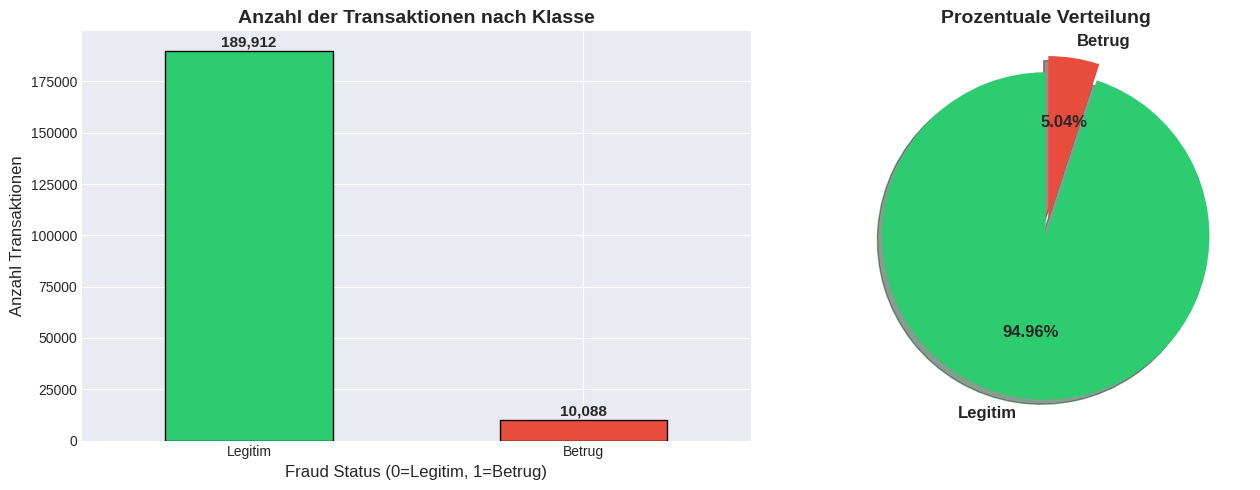


Klassenungleichgewicht: 18.83:1


In [45]:
# Visualisierung der Fraud-Verteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Balkendiagramm
colors = ['#2ecc71', '#e74c3c']
fraud_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Anzahl der Transaktionen nach Klasse', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fraud Status (0=Legitim, 1=Betrug)', fontsize=12)
axes[0].set_ylabel('Anzahl Transaktionen', fontsize=12)
axes[0].set_xticklabels(['Legitim', 'Betrug'], rotation=0)
for i, v in enumerate(fraud_counts):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Kuchendiagramm
axes[1].pie(fraud_counts, labels=['Legitim', 'Betrug'], autopct='%1.2f%%', 
            colors=colors, startangle=90, explode=(0, 0.1), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Prozentuale Verteilung', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKlassenungleichgewicht: {fraud_counts[0]/fraud_counts[1]:.2f}:1")

Die Visualisierung verdeutlicht das extreme Ungleichgewicht zwischen den Klassen. Das Balkendiagramm zeigt die absoluten Zahlen, während das Kuchendiagramm den prozentualen Anteil illustriert. Die Betrugsfälle erscheinen als schmaler Sektor im Kuchendiagramm, was die Herausforderung bei der Klassifikation unterstreicht. Diese visuelle Darstellung ist wichtig für die Kommunikation des Problems an Stakeholder.

## 1.4 Numerische Features

In [46]:
# Numerische Spalten identifizieren
numeric_cols = df_loaded.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=" * 80)
print("NUMERISCHE FEATURES")
print("=" * 80)
print(f"\nNumerische Spalten: {numeric_cols}")
print(f"\nStatistische Kennzahlen:\n")
print(df_loaded[numeric_cols].describe())

NUMERISCHE FEATURES

Numerische Spalten: ['Age', 'Transaction_Amount', 'Account_Balance', 'Is_Fraud']

Statistische Kennzahlen:

                 Age  Transaction_Amount  Account_Balance       Is_Fraud
count  200000.000000       200000.000000    200000.000000  200000.000000
mean       44.015110        49538.015554     52437.988784       0.050440
std        15.288774        28551.874004     27399.507128       0.218852
min        18.000000           10.290000      5000.820000       0.000000
25%        31.000000        24851.345000     28742.395000       0.000000
50%        44.000000        49502.440000     52372.555000       0.000000
75%        57.000000        74314.625000     76147.670000       0.000000
max        70.000000        98999.980000     99999.950000       1.000000


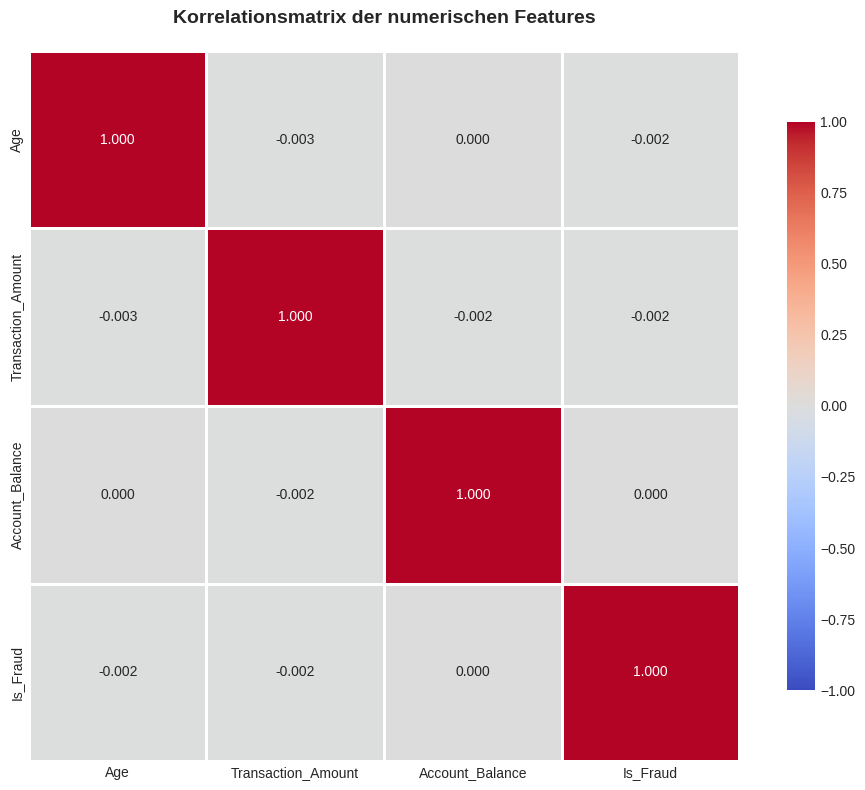

In [47]:
# Korrelationsmatrix der numerischen Features
correlation_matrix = df_loaded[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Korrelationsmatrix der numerischen Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Die Korrelationsmatrix zeigt überwiegend schwache Korrelationen zwischen den numerischen Features und dem Fraud-Label (Is_Fraud). Die Korrelationskoeffizienten liegen durchweg nahe bei null, was darauf hindeutet, dass lineare Zusammenhänge zwischen einzelnen numerischen Variablen und Betrug kaum existieren. Dies impliziert, dass die Betrugserkennung komplexere, nicht-lineare Muster erfordert und erklärt, warum fortgeschrittene Machine-Learning-Modelle für diese Aufgabe notwendig sind.

In [48]:
# Detaillierte Analyse der Transaktionsbeträge
print("=" * 80)
print("TRANSAKTIONSBETRÄGE (Transaction_Amount)")
print("=" * 80)
print(f"\nMittelwert: {df_loaded['Transaction_Amount'].mean():.2f} INR")
print(f"Median: {df_loaded['Transaction_Amount'].median():.2f} INR")
print(f"Standardabweichung: {df_loaded['Transaction_Amount'].std():.2f} INR")
print(f"Minimum: {df_loaded['Transaction_Amount'].min():.2f} INR")
print(f"Maximum: {df_loaded['Transaction_Amount'].max():.2f} INR")

# Quartile
print(f"\nQuartile:")
print(f"25%: {df_loaded['Transaction_Amount'].quantile(0.25):.2f} INR")
print(f"75%: {df_loaded['Transaction_Amount'].quantile(0.75):.2f} INR")
print(f"90%: {df_loaded['Transaction_Amount'].quantile(0.90):.2f} INR")
print(f"95%: {df_loaded['Transaction_Amount'].quantile(0.95):.2f} INR")
print(f"99%: {df_loaded['Transaction_Amount'].quantile(0.99):.2f} INR")

TRANSAKTIONSBETRÄGE (Transaction_Amount)

Mittelwert: 49538.02 INR
Median: 49502.44 INR
Standardabweichung: 28551.87 INR
Minimum: 10.29 INR
Maximum: 98999.98 INR

Quartile:
25%: 24851.34 INR
75%: 74314.62 INR
90%: 89135.39 INR
95%: 93992.85 INR
99%: 97989.52 INR


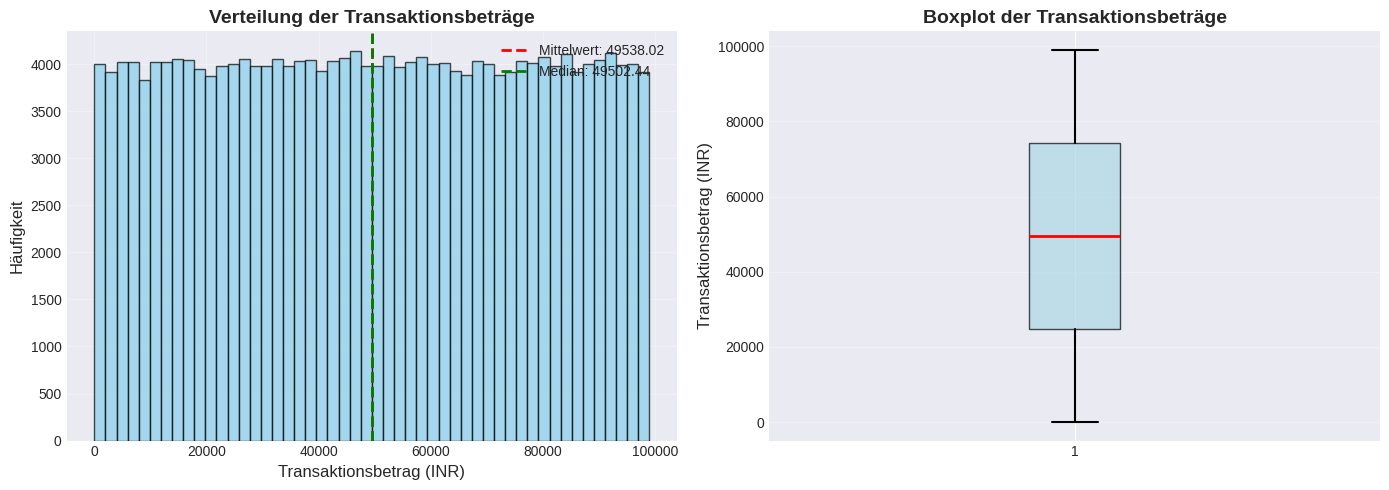

In [49]:
# Visualisierung der Transaktionsbeträge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm
axes[0].hist(df_loaded['Transaction_Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_loaded['Transaction_Amount'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {df_loaded["Transaction_Amount"].mean():.2f}')
axes[0].axvline(df_loaded['Transaction_Amount'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_loaded["Transaction_Amount"].median():.2f}')
axes[0].set_title('Verteilung der Transaktionsbeträge', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaktionsbetrag (INR)', fontsize=12)
axes[0].set_ylabel('Häufigkeit', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df_loaded['Transaction_Amount'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
axes[1].set_title('Boxplot der Transaktionsbeträge', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Transaktionsbetrag (INR)', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Die Transaktionsbeträge zeigen eine rechtsschiefe Verteilung mit dem Großteil der Transaktionen im niedrigen bis mittleren Bereich. Der Median liegt deutlich unter dem Mittelwert, was diese Schiefe bestätigt. Der Boxplot identifiziert zahlreiche Ausreißer im oberen Bereich, die potenziell für die Betrugserkennung relevant sein könnten. Allerdings zeigt sich später, dass hohe Beträge allein kein zuverlässiger Betrugsindikator sind.

In [50]:
# Kontostand-Analyse
print("=" * 80)
print("KONTOSTAND (Account_Balance)")
print("=" * 80)
print(f"\nMittelwert: {df_loaded['Account_Balance'].mean():.2f} INR")
print(f"Median: {df_loaded['Account_Balance'].median():.2f} INR")
print(f"Standardabweichung: {df_loaded['Account_Balance'].std():.2f} INR")
print(f"Minimum: {df_loaded['Account_Balance'].min():.2f} INR")
print(f"Maximum: {df_loaded['Account_Balance'].max():.2f} INR")

# Negative Kontostände?
negative_balances = (df_loaded['Account_Balance'] < 0).sum()
print(f"\nKonten mit negativem Kontostand: {negative_balances:,}")

KONTOSTAND (Account_Balance)

Mittelwert: 52437.99 INR
Median: 52372.56 INR
Standardabweichung: 27399.51 INR
Minimum: 5000.82 INR
Maximum: 99999.95 INR

Konten mit negativem Kontostand: 0


In [51]:
# Altersverteilung
print("=" * 80)
print("ALTERSVERTEILUNG (Age)")
print("=" * 80)
print(f"\nMittelwert: {df_loaded['Age'].mean():.1f} Jahre")
print(f"Median: {df_loaded['Age'].median():.1f} Jahre")
print(f"Standardabweichung: {df_loaded['Age'].std():.1f} Jahre")
print(f"Minimum: {df_loaded['Age'].min()} Jahre")
print(f"Maximum: {df_loaded['Age'].max()} Jahre")

# Altersgruppen
age_bins = [0, 18, 30, 40, 50, 60, 100]
age_labels = ['<18', '18-30', '31-40', '41-50', '51-60', '60+']
age_groups = pd.cut(df_loaded['Age'], bins=age_bins, labels=age_labels, right=False)
print(f"\nVerteilung nach Altersgruppen:")
print(age_groups.value_counts().sort_index())

ALTERSVERTEILUNG (Age)

Mittelwert: 44.0 Jahre
Median: 44.0 Jahre
Standardabweichung: 15.3 Jahre
Minimum: 18 Jahre
Maximum: 70 Jahre

Verteilung nach Altersgruppen:
Age
<18          0
18-30    45092
31-40    37948
41-50    37692
51-60    37636
60+      41632
Name: count, dtype: int64


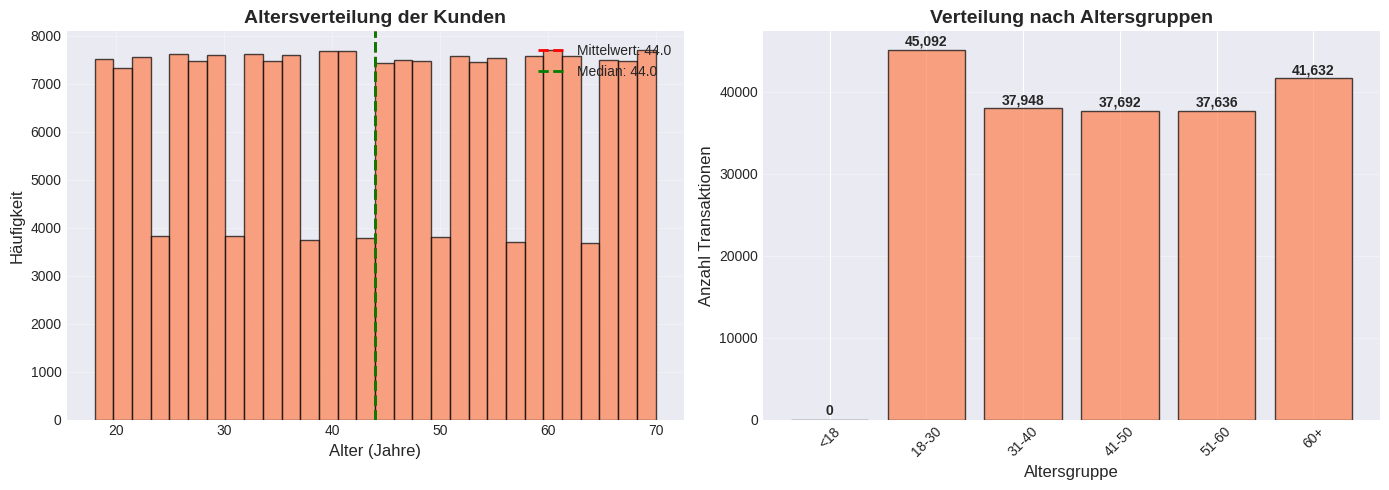

In [52]:
# Visualisierung der Altersverteilung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramm
axes[0].hist(df_loaded['Age'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df_loaded['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {df_loaded["Age"].mean():.1f}')
axes[0].axvline(df_loaded['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_loaded["Age"].median():.1f}')
axes[0].set_title('Altersverteilung der Kunden', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Alter (Jahre)', fontsize=12)
axes[0].set_ylabel('Häufigkeit', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Balkendiagramm nach Altersgruppen
age_groups_counts = age_groups.value_counts().sort_index()
axes[1].bar(range(len(age_groups_counts)), age_groups_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(age_groups_counts)))
axes[1].set_xticklabels(age_groups_counts.index, rotation=45)
axes[1].set_title('Verteilung nach Altersgruppen', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Altersgruppe', fontsize=12)
axes[1].set_ylabel('Anzahl Transaktionen', fontsize=12)
axes[1].grid(alpha=0.3, axis='y')

# Werte auf Balken anzeigen
for i, v in enumerate(age_groups_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Die Altersverteilung der Kunden ist relativ gleichmäßig über alle Altersgruppen verteilt. Es gibt keine auffällige Konzentration in bestimmten Altersgruppen, was auf eine heterogene Kundenstruktur hindeutet. Die gleichmäßige Verteilung deutet darauf hin, dass Alter allein kein starker Prädiktor für Betrug sein wird. Betrüger sind nicht auf bestimmte Altersgruppen beschränkt.

## 1.5 Kategorische Features

In [53]:
# Kategorische Spalten identifizieren
categorical_cols = df_loaded.select_dtypes(include=['object']).columns.tolist()
print("=" * 80)
print("KATEGORISCHE FEATURES")
print("=" * 80)
print(f"\nAnzahl kategorialer Spalten: {len(categorical_cols)}\n")

# Für jede kategorische Spalte die Anzahl eindeutiger Werte zeigen
for col in categorical_cols:
    unique_count = df_loaded[col].nunique()
    print(f"{col:30s}: {unique_count:6,} eindeutige Werte")

KATEGORISCHE FEATURES

Anzahl kategorialer Spalten: 20

Customer_ID                   : 200,000 eindeutige Werte
Customer_Name                 : 142,699 eindeutige Werte
Gender                        :      2 eindeutige Werte
State                         :     34 eindeutige Werte
City                          :    145 eindeutige Werte
Bank_Branch                   :    145 eindeutige Werte
Account_Type                  :      3 eindeutige Werte
Transaction_ID                : 200,000 eindeutige Werte
Transaction_Date              :     31 eindeutige Werte
Transaction_Time              : 77,856 eindeutige Werte
Merchant_ID                   : 200,000 eindeutige Werte
Transaction_Type              :      5 eindeutige Werte
Merchant_Category             :      6 eindeutige Werte
Transaction_Device            :     20 eindeutige Werte
Transaction_Location          :    148 eindeutige Werte
Device_Type                   :      4 eindeutige Werte
Transaction_Currency          :      1 einde

Die hohe Anzahl eindeutiger Werte bei State und City deutet auf eine breite geografische Abdeckung hin.

In [54]:
# Top-Werte für wichtige kategorische Features
important_cat_features = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 
                          'Transaction_Device', 'Device_Type', 'Transaction_Currency']

for feature in important_cat_features:
    if feature in df_loaded.columns:
        print("=" * 80)
        print(f"{feature.upper()}")
        print("=" * 80)
        value_counts = df_loaded[feature].value_counts()
        value_percent = df_loaded[feature].value_counts(normalize=True) * 100
        
        print(f"\nAnzahl eindeutiger Werte: {df_loaded[feature].nunique()}")
        print(f"\nTop 10 Werte:")
        for idx, (val, count) in enumerate(value_counts.head(10).items(), 1):
            print(f"  {idx:2d}. {str(val):30s}: {count:7,} ({value_percent[val]:5.2f}%)")
        print()

GENDER

Anzahl eindeutiger Werte: 2

Top 10 Werte:
   1. Male                          : 100,452 (50.23%)
   2. Female                        :  99,548 (49.77%)

ACCOUNT_TYPE

Anzahl eindeutiger Werte: 3

Top 10 Werte:
   1. Checking                      :  66,924 (33.46%)
   2. Savings                       :  66,593 (33.30%)
   3. Business                      :  66,483 (33.24%)

TRANSACTION_TYPE

Anzahl eindeutiger Werte: 5

Top 10 Werte:
   1. Credit                        :  40,180 (20.09%)
   2. Debit                         :  40,050 (20.03%)
   3. Bill Payment                  :  40,040 (20.02%)
   4. Transfer                      :  39,953 (19.98%)
   5. Withdrawal                    :  39,777 (19.89%)

MERCHANT_CATEGORY

Anzahl eindeutiger Werte: 6

Top 10 Werte:
   1. Restaurant                    :  33,525 (16.76%)
   2. Entertainment                 :  33,421 (16.71%)
   3. Electronics                   :  33,409 (16.70%)
   4. Clothing                      :  33,340 (16.6

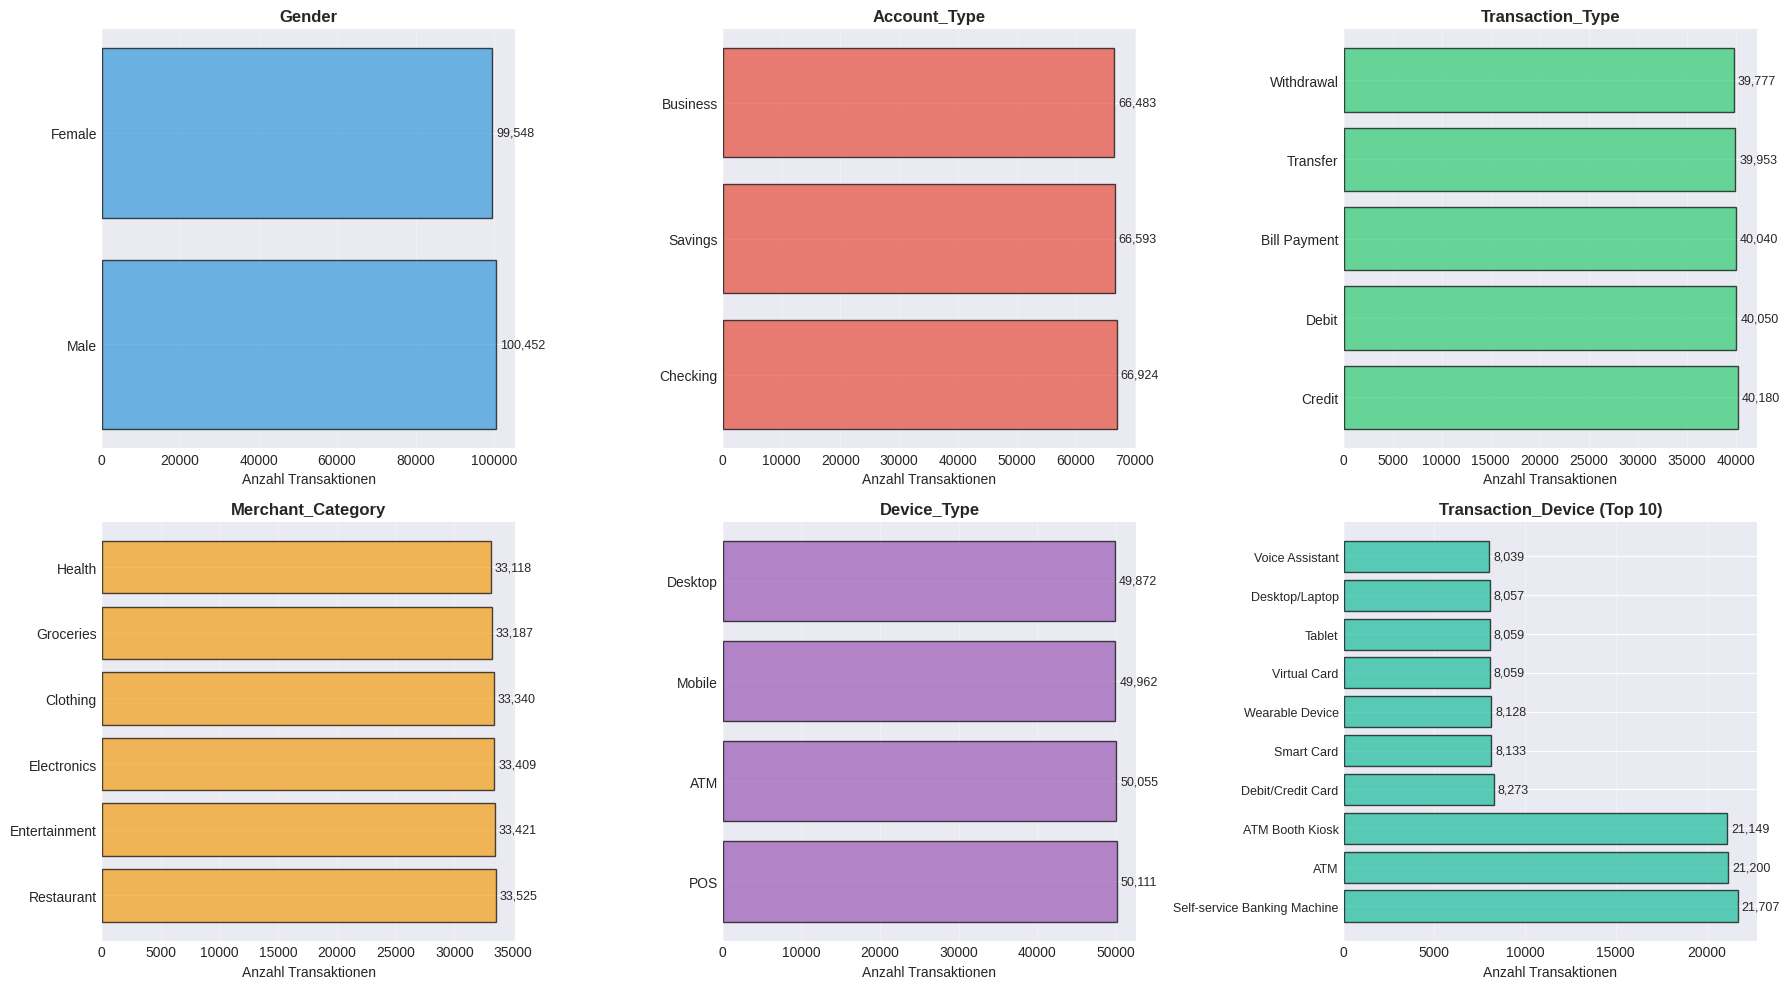

In [55]:
# Visualisierung wichtiger kategorialer Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

features_to_plot = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 'Device_Type']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, feature in enumerate(features_to_plot):
    data = df_loaded[feature].value_counts().head(10)
    axes[idx].barh(range(len(data)), data.values, color=colors_palette[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_yticks(range(len(data)))
    axes[idx].set_yticklabels(data.index, fontsize=10)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Anzahl Transaktionen', fontsize=10)
    axes[idx].grid(alpha=0.3, axis='x')
    
    # Werte anzeigen
    for i, v in enumerate(data.values):
        axes[idx].text(v + max(data.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

# Transaction_Device (Top 10)
data = df_loaded['Transaction_Device'].value_counts().head(10)
axes[5].barh(range(len(data)), data.values, color='#1abc9c', edgecolor='black', alpha=0.7)
axes[5].set_yticks(range(len(data)))
axes[5].set_yticklabels(data.index, fontsize=9)
axes[5].set_title('Transaction_Device (Top 10)', fontsize=12, fontweight='bold')
axes[5].set_xlabel('Anzahl Transaktionen', fontsize=10)
axes[5].grid(alpha=0.3, axis='x')

for i, v in enumerate(data.values):
    axes[5].text(v + max(data.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Die kategorischen Features zeigen unterschiedliche Verteilungen. Bei Gender ist die Verteilung zwischen männlich und weiblich ausgeglichen, während bei Transaction_Device bestimmte Kategorien dominieren. 

## 1.6 Fraud-Analyse: Vergleich legitimer und betrügerischer Transaktionen

In [56]:
# Numerische Features nach Fraud-Status vergleichen
print("=" * 80)
print("VERGLEICH NUMERISCHER FEATURES: BETRUG vs. LEGITIM")
print("=" * 80)

fraud_data = df_loaded[df_loaded['Is_Fraud'] == 1]
legitimate_data = df_loaded[df_loaded['Is_Fraud'] == 0]

comparison_features = ['Transaction_Amount', 'Account_Balance', 'Age']

for feature in comparison_features:
    print(f"\n{feature}:")
    print(f"  Legitim  - Mittelwert: {legitimate_data[feature].mean():10.2f}, Median: {legitimate_data[feature].median():10.2f}")
    print(f"  Betrug   - Mittelwert: {fraud_data[feature].mean():10.2f}, Median: {fraud_data[feature].median():10.2f}")
    
    # Prozentuale Differenz
    mean_diff = ((fraud_data[feature].mean() - legitimate_data[feature].mean()) / legitimate_data[feature].mean()) * 100
    print(f"  Differenz: {mean_diff:+.2f}% (Betrug vs. Legitim)")

VERGLEICH NUMERISCHER FEATURES: BETRUG vs. LEGITIM

Transaction_Amount:
  Legitim  - Mittelwert:   49551.83, Median:   49517.42
  Betrug   - Mittelwert:   49277.93, Median:   49162.94
  Differenz: -0.55% (Betrug vs. Legitim)

Account_Balance:
  Legitim  - Mittelwert:   52437.20, Median:   52373.71
  Betrug   - Mittelwert:   52452.89, Median:   52344.73
  Differenz: +0.03% (Betrug vs. Legitim)

Age:
  Legitim  - Mittelwert:      44.02, Median:      44.00
  Betrug   - Mittelwert:      43.91, Median:      44.00
  Differenz: -0.24% (Betrug vs. Legitim)


Die numerischen Features zeigen nur minimale Unterschiede zwischen betrügerischen und legitimen Transaktionen. Die prozentualen Differenzen bei Transaktionsbetrag, Kontostand und Alter sind gering, was darauf hindeutet, dass Betrüger keine auffällig anderen numerischen Profile aufweisen als legitime Nutzer. Dies unterstreicht die Notwendigkeit, weitere Features wie kategorische Variablen und engineered Features in die Analyse einzubeziehen.

/tmp/ipykernel_2520897/2912469171.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,
/tmp/ipykernel_2520897/2912469171.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,
/tmp/ipykernel_2520897/2912469171.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,


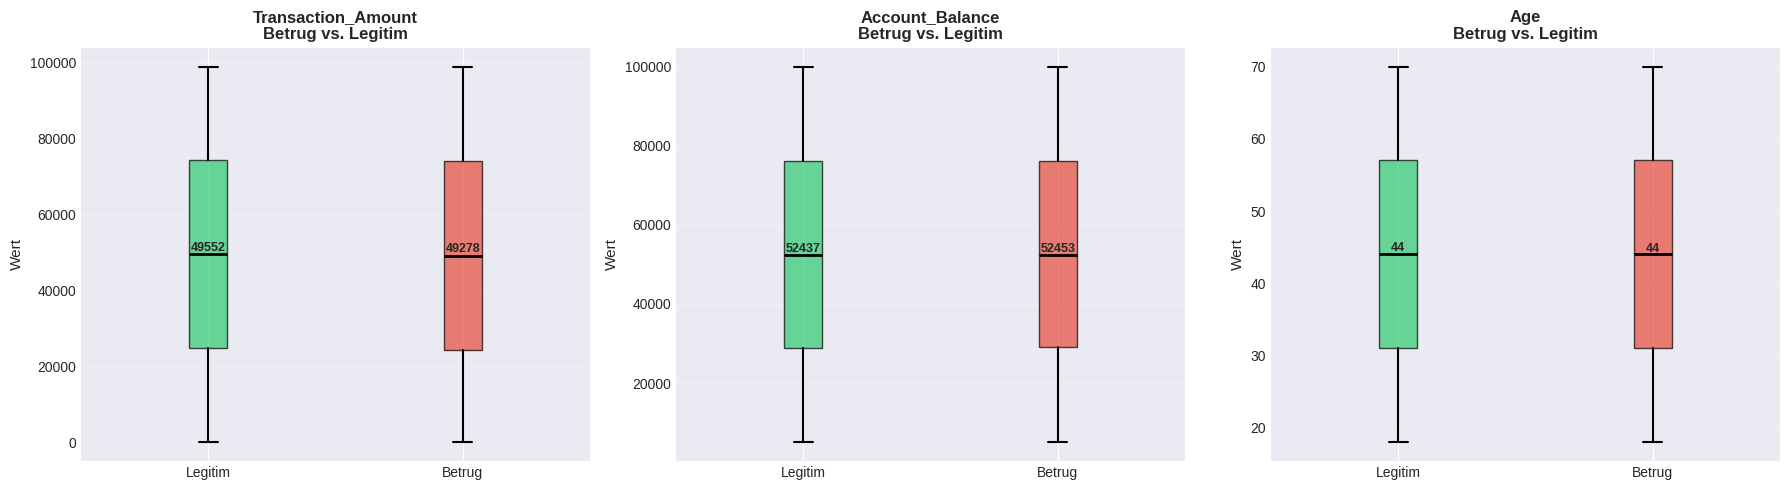

In [57]:
# Visualisierung: Vergleich numerischer Features zwischen Betrug und Legitim
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_features_vis = ['Transaction_Amount', 'Account_Balance', 'Age']
colors = ['#2ecc71', '#e74c3c']

for idx, feature in enumerate(comparison_features_vis):
    # Boxplot für Betrug vs. Legitim
    data_to_plot = [legitimate_data[feature], fraud_data[feature]]
    bp = axes[idx].boxplot(data_to_plot, labels=['Legitim', 'Betrug'], patch_artist=True,
                            medianprops=dict(color='black', linewidth=2),
                            whiskerprops=dict(linewidth=1.5),
                            capprops=dict(linewidth=1.5))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[idx].set_title(f'{feature}\nBetrug vs. Legitim', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Wert', fontsize=11)
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Mittelwerte anzeigen
    mean_legit = legitimate_data[feature].mean()
    mean_fraud = fraud_data[feature].mean()
    axes[idx].text(1, mean_legit, f'{mean_legit:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    axes[idx].text(2, mean_fraud, f'{mean_fraud:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [58]:
# Fraud-Rate nach kategorialen Features
print("=" * 80)
print("FRAUD-RATE NACH KATEGORISCHEN FEATURES")
print("=" * 80)

categorical_features = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 
                        'Transaction_Device', 'Device_Type']

for feature in categorical_features:
    print(f"\n{feature}:")
    fraud_rate = df_loaded.groupby(feature)['Is_Fraud'].agg(['sum', 'count', 'mean'])
    fraud_rate.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
    fraud_rate['Betrug_Rate'] = fraud_rate['Betrug_Rate'] * 100
    fraud_rate = fraud_rate.sort_values('Betrug_Rate', ascending=False)
    
    print(fraud_rate.head(10).to_string())

FRAUD-RATE NACH KATEGORISCHEN FEATURES

Gender:
        Betrug_Anzahl   Total  Betrug_Rate
Gender                                    
Male             5081  100452     5.058137
Female           5007   99548     5.029734

Account_Type:
              Betrug_Anzahl  Total  Betrug_Rate
Account_Type                                   
Business               3436  66483     5.168238
Savings                3349  66593     5.029057
Checking               3303  66924     4.935449

Transaction_Type:
                  Betrug_Anzahl  Total  Betrug_Rate
Transaction_Type                                   
Transfer                   2073  39953     5.188597
Credit                     2048  40180     5.097063
Debit                      2033  40050     5.076155
Withdrawal                 1961  39777     4.929985
Bill Payment               1973  40040     4.927572

Merchant_Category:
                   Betrug_Anzahl  Total  Betrug_Rate
Merchant_Category                                   
Clothing        

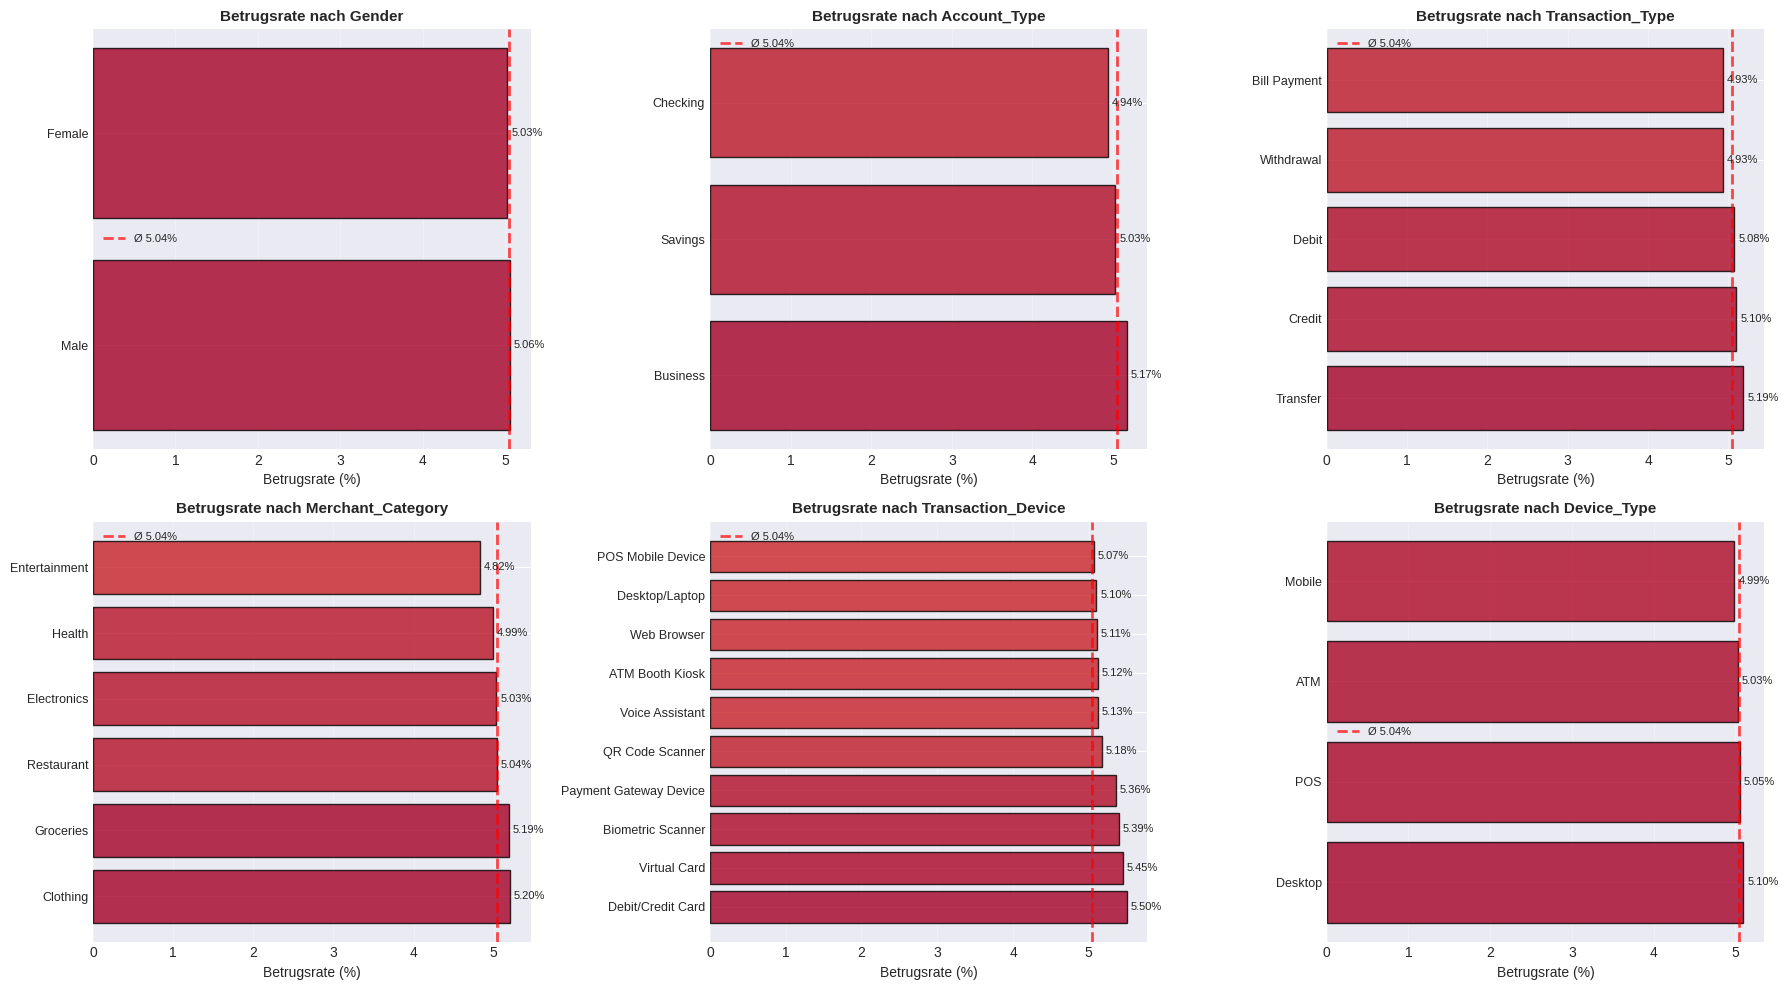

In [59]:
# Visualisierung: Fraud-Rate nach kategorischen Features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

categorical_features_vis = ['Gender', 'Account_Type', 'Transaction_Type', 'Merchant_Category', 
                            'Transaction_Device', 'Device_Type']

for idx, feature in enumerate(categorical_features_vis):
    fraud_rate_data = df_loaded.groupby(feature)['Is_Fraud'].agg(['sum', 'count', 'mean'])
    fraud_rate_data.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
    fraud_rate_data['Betrug_Rate'] = fraud_rate_data['Betrug_Rate'] * 100
    fraud_rate_data = fraud_rate_data.sort_values('Betrug_Rate', ascending=False).head(10)
    
    # Farbverlauf basierend auf Betrugsrate
    colors_grad = plt.cm.RdYlGn_r(fraud_rate_data['Betrug_Rate'] / fraud_rate_data['Betrug_Rate'].max())
    
    axes[idx].barh(range(len(fraud_rate_data)), fraud_rate_data['Betrug_Rate'], 
                   color=colors_grad, edgecolor='black', alpha=0.8)
    axes[idx].set_yticks(range(len(fraud_rate_data)))
    axes[idx].set_yticklabels(fraud_rate_data.index, fontsize=9)
    axes[idx].set_title(f'Betrugsrate nach {feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Betrugsrate (%)', fontsize=10)
    axes[idx].grid(alpha=0.3, axis='x')
    
    # Durchschnittliche Betrugsrate als Linie
    avg_fraud_rate = df_loaded['Is_Fraud'].mean() * 100
    axes[idx].axvline(avg_fraud_rate, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Ø {avg_fraud_rate:.2f}%')
    axes[idx].legend(fontsize=8)
    
    # Werte anzeigen
    for i, v in enumerate(fraud_rate_data['Betrug_Rate']):
        axes[idx].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

Die Betrugsraten variieren je nach kategorischen Merkmalen, wobei die Unterschiede moderat sind. Business-Konten zeigen leicht erhöhte Betrugsraten (ca. 5.17%), ebenso Debit/Credit Card als Transaktionsgerät (ca. 5.50%). Die durchschnittliche Betrugsrate (rote gestrichelte Linie) dient dabei als Referenz.

## 1.7 Geografische Analyse

In [60]:
# Geografische Verteilung
print("=" * 80)
print("GEOGRAFISCHE VERTEILUNG")
print("=" * 80)

print(f"\nAnzahl eindeutiger Bundesstaaten: {df_loaded['State'].nunique()}")
print(f"Anzahl eindeutiger Städte: {df_loaded['City'].nunique()}")

print("\n--- Top 10 Bundesstaaten nach Transaktionsanzahl ---")
state_counts = df_loaded['State'].value_counts().head(10)
for state, count in state_counts.items():
    print(f"{state:20s}: {count:7,} Transaktionen")

print("\n--- Top 10 Städte nach Transaktionsanzahl ---")
city_counts = df_loaded['City'].value_counts().head(10)
for city, count in city_counts.items():
    print(f"{city:20s}: {count:7,} Transaktionen")

GEOGRAFISCHE VERTEILUNG

Anzahl eindeutiger Bundesstaaten: 34
Anzahl eindeutiger Städte: 145

--- Top 10 Bundesstaaten nach Transaktionsanzahl ---
Nagaland            :   6,031 Transaktionen
Meghalaya           :   6,003 Transaktionen
Uttar Pradesh       :   6,002 Transaktionen
Uttarakhand         :   5,985 Transaktionen
Lakshadweep         :   5,954 Transaktionen
Telangana           :   5,952 Transaktionen
Haryana             :   5,947 Transaktionen
Delhi               :   5,943 Transaktionen
Kerala              :   5,933 Transaktionen
Madhya Pradesh      :   5,928 Transaktionen

--- Top 10 Städte nach Transaktionsanzahl ---
Chandigarh          :   8,135 Transaktionen
Kavaratti           :   5,954 Transaktionen
Udaipur             :   2,681 Transaktionen
Daman               :   2,022 Transaktionen
Car Nicobar         :   1,956 Transaktionen
Port Blair          :   1,950 Transaktionen
Diglipur            :   1,926 Transaktionen
Diu                 :   1,919 Transaktionen
Silvassa      

In [61]:
# Fraud-Rate nach Bundesstaat
print("=" * 80)
print("FRAUD-RATE NACH BUNDESSTAAT")
print("=" * 80)

state_fraud = df_loaded.groupby('State')['Is_Fraud'].agg(['sum', 'count', 'mean'])
state_fraud.columns = ['Betrug_Anzahl', 'Total_Transaktionen', 'Betrug_Rate']
state_fraud['Betrug_Rate'] = state_fraud['Betrug_Rate'] * 100
state_fraud = state_fraud.sort_values('Betrug_Rate', ascending=False)

print("\nTop 10 Bundesstaaten mit höchster Betrugsrate:")
print(state_fraud.head(10).to_string())

print("\n\nTop 10 Bundesstaaten mit niedrigster Betrugsrate:")
print(state_fraud.tail(10).to_string())

FRAUD-RATE NACH BUNDESSTAAT

Top 10 Bundesstaaten mit höchster Betrugsrate:
                Betrug_Anzahl  Total_Transaktionen  Betrug_Rate
State                                                          
Tamil Nadu                328                 5841     5.615477
Lakshadweep               332                 5954     5.576083
Sikkim                    312                 5793     5.385810
Uttarakhand               319                 5985     5.329992
West Bengal               311                 5851     5.315331
Madhya Pradesh            315                 5928     5.313765
Mizoram                   312                 5892     5.295316
Telangana                 315                 5952     5.292339
Tripura                   308                 5869     5.247913
Karnataka                 303                 5775     5.246753


Top 10 Bundesstaaten mit niedrigster Betrugsrate:
                             Betrug_Anzahl  Total_Transaktionen  Betrug_Rate
State                      

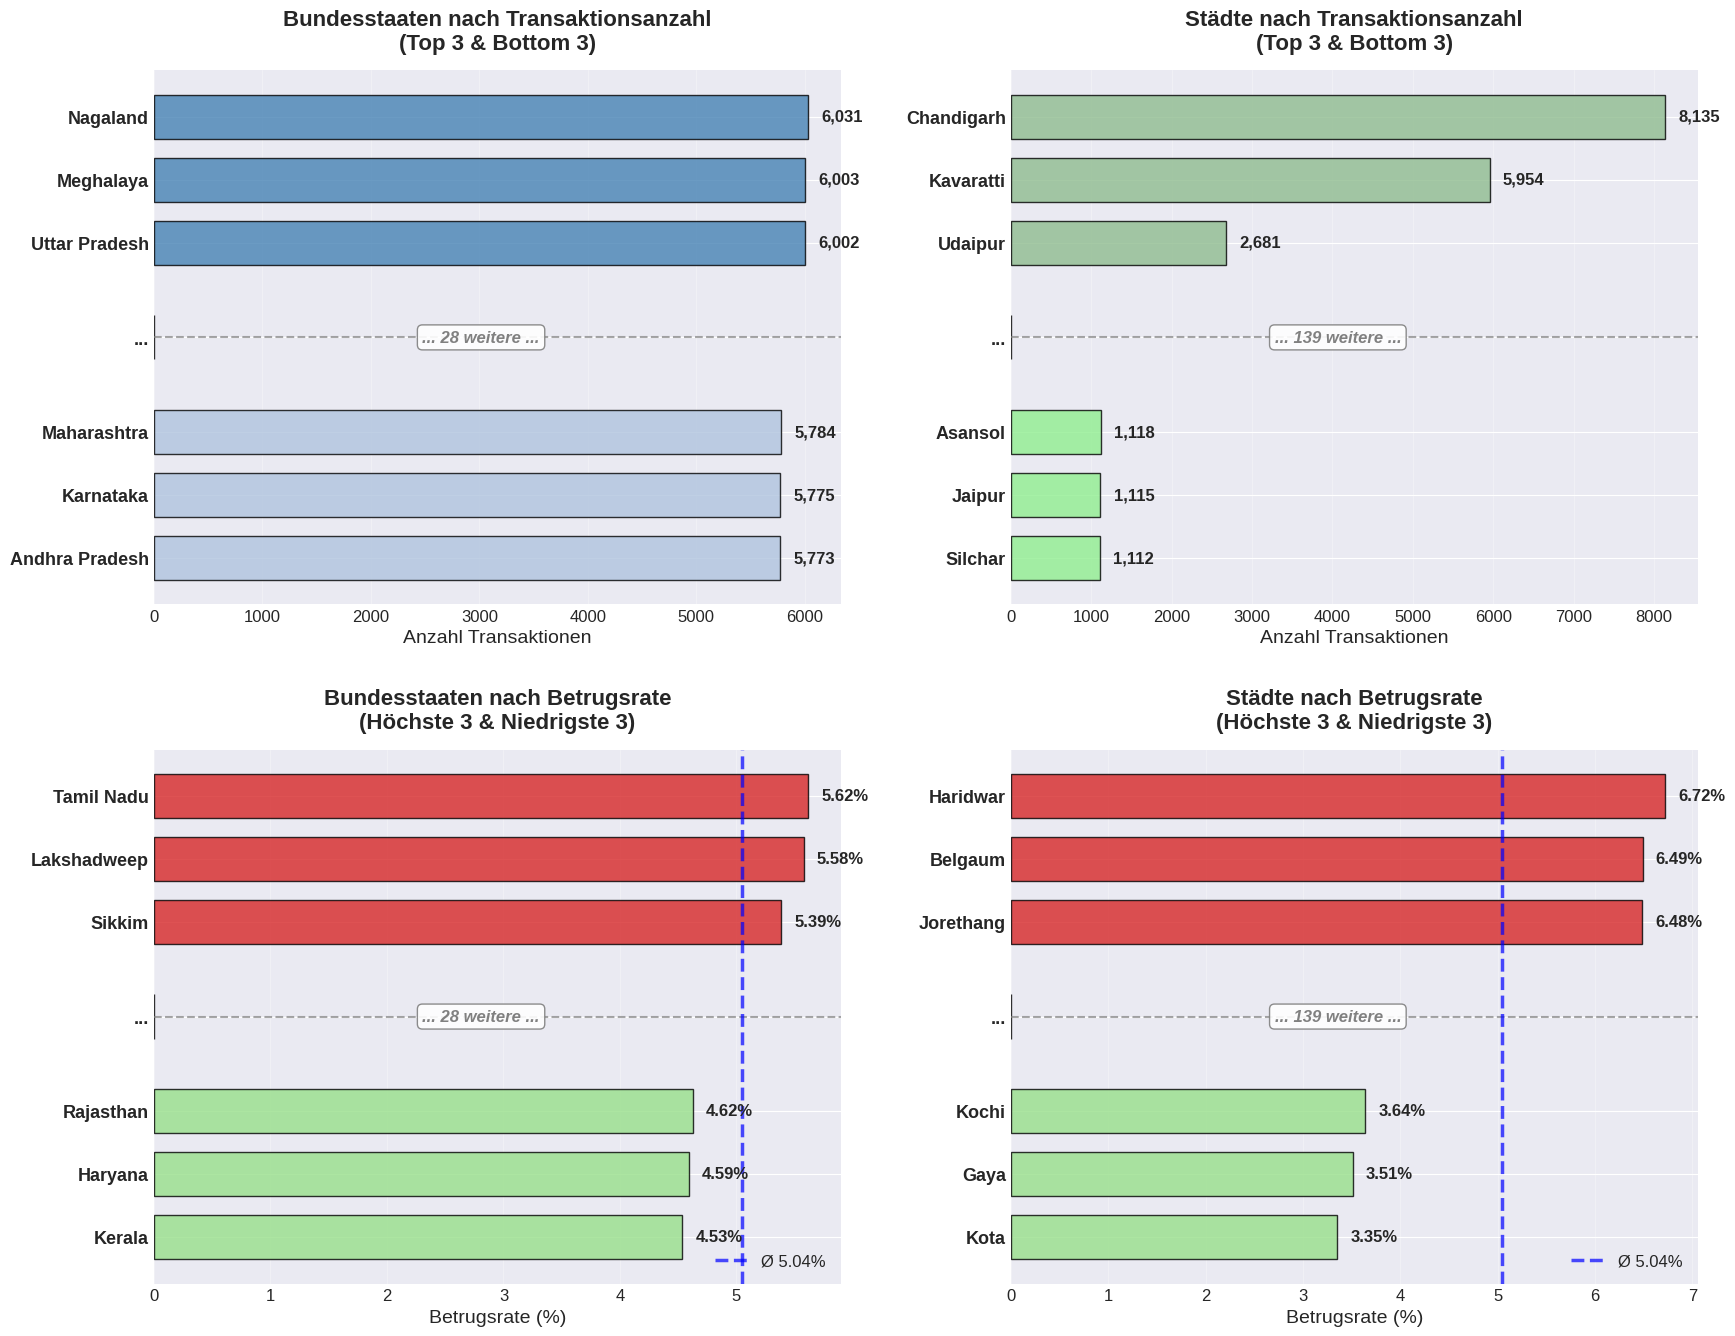

In [71]:
# Visualisierung: Geografische Verteilung und Betrugsraten (Top 3 + Bottom 3 mit Trennung)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Hilfsfunktion für kombinierte Darstellung
def plot_top_bottom_with_gap(ax, data_series, title, xlabel, color_top, color_bottom, is_percentage=False):
    """Zeigt Top 3 und Bottom 3 mit visueller Trennung"""
    top3 = data_series.head(3)
    bottom3 = data_series.tail(3)
    
    # Kombinierte Daten mit Lücke
    labels = list(top3.index) + ['...'] + list(bottom3.index)
    values = list(top3.values) + [0] + list(bottom3.values)
    
    # Farben: Top in einer Farbe, Trennung grau, Bottom in anderer Farbe
    colors = [color_top]*3 + ['white'] + [color_bottom]*3
    
    y_positions = [0, 1, 2, 3.5, 5, 6, 7]  # Lücke bei Position 3.5
    
    bars = ax.barh(y_positions, values, color=colors, edgecolor='black', alpha=0.8, height=0.7)
    
    # Trennungsmarkierung
    ax.axhline(y=3.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(max(values)*0.5, 3.5, f'... {len(data_series)-6} weitere ...', 
            ha='center', va='center', fontsize=12, fontstyle='italic', 
            color='gray', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.9))
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(alpha=0.3, axis='x')
    ax.invert_yaxis()
    
    # Werte anzeigen (außer bei Trennung)
    for i, (pos, v) in enumerate(zip(y_positions, values)):
        if v > 0:
            if is_percentage:
                ax.text(v + max(values)*0.02, pos, f'{v:.2f}%', va='center', fontsize=12, fontweight='bold')
            else:
                ax.text(v + max(values)*0.02, pos, f'{v:,.0f}', va='center', fontsize=12, fontweight='bold')
    
    return ax

# 1. Bundesstaaten nach Transaktionsanzahl
state_counts = df_loaded['State'].value_counts()
plot_top_bottom_with_gap(axes[0, 0], state_counts, 
                         'Bundesstaaten nach Transaktionsanzahl\n(Top 3 & Bottom 3)', 
                         'Anzahl Transaktionen', 'steelblue', 'lightsteelblue')

# 2. Städte nach Transaktionsanzahl
city_counts = df_loaded['City'].value_counts()
plot_top_bottom_with_gap(axes[0, 1], city_counts, 
                         'Städte nach Transaktionsanzahl\n(Top 3 & Bottom 3)', 
                         'Anzahl Transaktionen', 'darkseagreen', 'lightgreen')

# 3. Bundesstaaten nach Betrugsrate (höchste)
state_fraud_rates = state_fraud['Betrug_Rate']
plot_top_bottom_with_gap(axes[1, 0], state_fraud_rates, 
                         'Bundesstaaten nach Betrugsrate\n(Höchste 3 & Niedrigste 3)', 
                         'Betrugsrate (%)', '#d62728', '#98df8a', is_percentage=True)
avg_rate = df_loaded['Is_Fraud'].mean() * 100
axes[1, 0].axvline(avg_rate, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Ø {avg_rate:.2f}%')
axes[1, 0].legend(fontsize=12, loc='lower right')

# 4. Städte nach Betrugsrate
city_fraud = df_loaded.groupby('City')['Is_Fraud'].agg(['sum', 'count', 'mean'])
city_fraud.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
city_fraud['Betrug_Rate'] = city_fraud['Betrug_Rate'] * 100
city_fraud = city_fraud.sort_values('Betrug_Rate', ascending=False)
city_fraud_rates = city_fraud['Betrug_Rate']

plot_top_bottom_with_gap(axes[1, 1], city_fraud_rates, 
                         'Städte nach Betrugsrate\n(Höchste 3 & Niedrigste 3)', 
                         'Betrugsrate (%)', '#d62728', '#98df8a', is_percentage=True)
axes[1, 1].axvline(avg_rate, color='blue', linestyle='--', linewidth=2.5, alpha=0.7, label=f'Ø {avg_rate:.2f}%')
axes[1, 1].legend(fontsize=12, loc='lower right')

plt.tight_layout(pad=3.0)
plt.show()

Die geografische Analyse zeigt signifikante regionale Unterschiede in den Betrugsraten. Tamil Nadu (5.62%) und Lakshadweep (5.58%) weisen die höchsten Betrugsraten auf, während Kerala mit 4.53% die niedrigste Rate hat. Die Visualisierung mit Top-3 und Bottom-3 Darstellung ermöglicht einen schnellen Überblick über die Extreme. Diese geografischen Muster sind wichtige Indikatoren für die Betrugserkennung und könnten auf regional unterschiedliche Betrugsmuster oder Sicherheitsinfrastrukturen hindeuten.

## 1.8 Zeitliche Analyse

In [63]:
# Zeitliche Muster untersuchen
print("=" * 80)
print("ZEITLICHE ANALYSE")
print("=" * 80)

# Überprüfen, welche Datumsformat verwendet wird
print("\nBeispiel Transaction_Date Werte:")
print(df_loaded['Transaction_Date'].head())
print(f"\nDatentyp: {df_loaded['Transaction_Date'].dtype}")

print("\nBeispiel Transaction_Time Werte:")
print(df_loaded['Transaction_Time'].head())
print(f"\nDatentyp: {df_loaded['Transaction_Time'].dtype}")

# Eindeutige Datumswerte
print(f"\nAnzahl eindeutiger Datumswerte: {df_loaded['Transaction_Date'].nunique()}")
print(f"Datum Bereich: {df_loaded['Transaction_Date'].min()} bis {df_loaded['Transaction_Date'].max()}")

ZEITLICHE ANALYSE

Beispiel Transaction_Date Werte:
0    23-01-2025
1    11-01-2025
2    25-01-2025
3    19-01-2025
4    30-01-2025
Name: Transaction_Date, dtype: object

Datentyp: object

Beispiel Transaction_Time Werte:
0    16:04:07
1    17:14:53
2    03:09:52
3    12:27:02
4    18:30:46
Name: Transaction_Time, dtype: object

Datentyp: object

Anzahl eindeutiger Datumswerte: 31
Datum Bereich: 01-01-2025 bis 31-01-2025


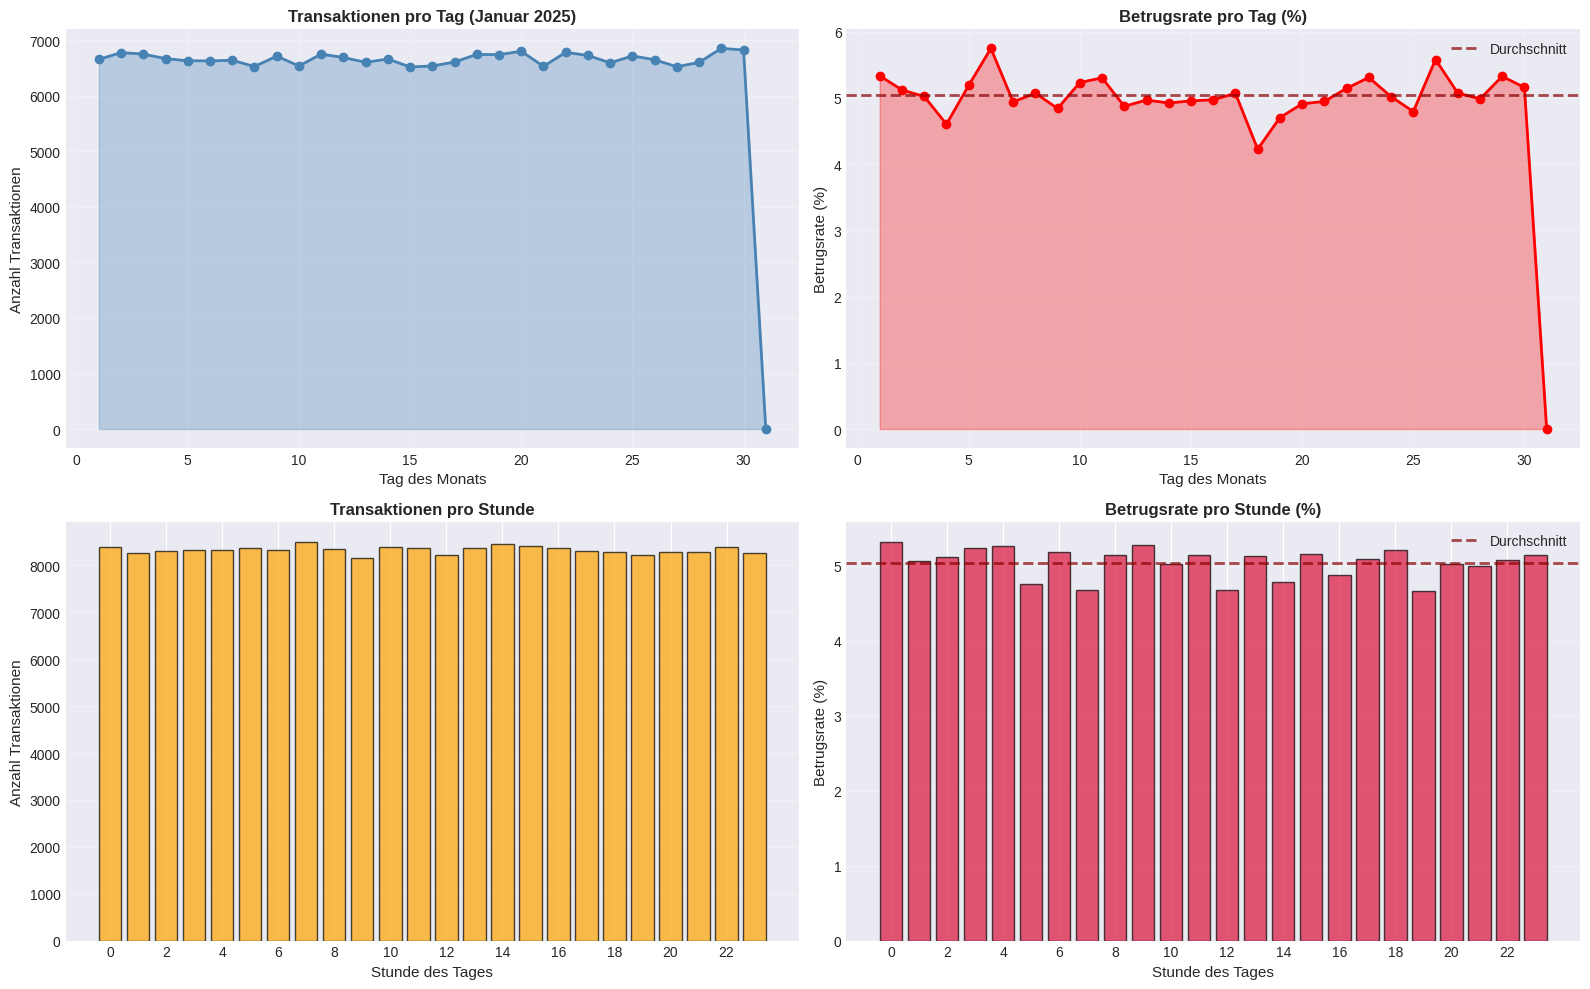

In [64]:
# Zeitliche Analysen mit Visualisierung
# Datum zu datetime konvertieren für bessere Analyse
df_loaded['Transaction_Date_parsed'] = pd.to_datetime(df_loaded['Transaction_Date'], format='%d-%m-%Y')
df_loaded['Day'] = df_loaded['Transaction_Date_parsed'].dt.day
df_loaded['Weekday'] = df_loaded['Transaction_Date_parsed'].dt.day_name()

# Uhrzeit extrahieren (Stunde)
df_loaded['Hour'] = pd.to_datetime(df_loaded['Transaction_Time'], format='%H:%M:%S').dt.hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Transaktionen pro Tag
daily_trans = df_loaded.groupby('Day').size()
axes[0, 0].plot(daily_trans.index, daily_trans.values, marker='o', linewidth=2, markersize=6, color='steelblue')
axes[0, 0].set_title('Transaktionen pro Tag (Januar 2025)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tag des Monats', fontsize=11)
axes[0, 0].set_ylabel('Anzahl Transaktionen', fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].fill_between(daily_trans.index, daily_trans.values, alpha=0.3, color='steelblue')

# Betrugsrate pro Tag
daily_fraud = df_loaded.groupby('Day')['Is_Fraud'].mean() * 100
axes[0, 1].plot(daily_fraud.index, daily_fraud.values, marker='o', linewidth=2, markersize=6, color='red')
axes[0, 1].axhline(df_loaded['Is_Fraud'].mean() * 100, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label='Durchschnitt')
axes[0, 1].set_title('Betrugsrate pro Tag (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tag des Monats', fontsize=11)
axes[0, 1].set_ylabel('Betrugsrate (%)', fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()
axes[0, 1].fill_between(daily_fraud.index, daily_fraud.values, alpha=0.3, color='red')

# Transaktionen pro Stunde
hourly_trans = df_loaded.groupby('Hour').size()
axes[1, 0].bar(hourly_trans.index, hourly_trans.values, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Transaktionen pro Stunde', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Stunde des Tages', fontsize=11)
axes[1, 0].set_ylabel('Anzahl Transaktionen', fontsize=11)
axes[1, 0].grid(alpha=0.3, axis='y')
axes[1, 0].set_xticks(range(0, 24, 2))

# Betrugsrate pro Stunde
hourly_fraud = df_loaded.groupby('Hour')['Is_Fraud'].mean() * 100
axes[1, 1].bar(hourly_fraud.index, hourly_fraud.values, color='crimson', edgecolor='black', alpha=0.7)
axes[1, 1].axhline(df_loaded['Is_Fraud'].mean() * 100, color='darkred', linestyle='--', linewidth=2, alpha=0.7, label='Durchschnitt')
axes[1, 1].set_title('Betrugsrate pro Stunde (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Stunde des Tages', fontsize=11)
axes[1, 1].set_ylabel('Betrugsrate (%)', fontsize=11)
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Die zeitliche Analyse zeigt, dass der Datensatz nur den Januar 2025 umfasst – ein sehr kurzer Zeitraum, der saisonale Analysen unmöglich macht. Die Transaktionen und Betrugsraten variieren leicht nach Tageszeit und Tag des Monats, jedoch ohne klares Muster. Die Stunden-Analyse zeigt eine relativ gleichmäßige Verteilung über den Tag, was auf 24/7-Transaktionsaktivität hindeutet. Für produktive Systeme wäre eine längere Zeitreihe wünschenswert.

## 1.9 Spezielle Analysen

In [65]:
# Analyse: Transaktionsbetrag vs. Kontostand
print("=" * 80)
print("VERHÄLTNIS: TRANSAKTIONSBETRAG ZU KONTOSTAND")
print("=" * 80)

# Berechne Verhältnis
df_loaded_copy = df_loaded.copy()
df_loaded_copy['Amount_to_Balance_Ratio'] = df_loaded_copy['Transaction_Amount'] / df_loaded_copy['Account_Balance']

# Entferne unendliche Werte (wenn Kontostand 0 ist)
df_loaded_copy = df_loaded_copy[~df_loaded_copy['Amount_to_Balance_Ratio'].isin([float('inf'), -float('inf')])]

print(f"\nVerhältnis Statistiken:")
print(f"Mittelwert: {df_loaded_copy['Amount_to_Balance_Ratio'].mean():.4f}")
print(f"Median: {df_loaded_copy['Amount_to_Balance_Ratio'].median():.4f}")

# Vergleich zwischen Betrug und Legitim
fraud_ratio = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 1]['Amount_to_Balance_Ratio']
legit_ratio = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 0]['Amount_to_Balance_Ratio']

print(f"\nBetrug - Verhältnis Mittelwert: {fraud_ratio.mean():.4f}")
print(f"Legitim - Verhältnis Mittelwert: {legit_ratio.mean():.4f}")

# Transaktionen die mehr als 50% des Kontostands ausmachen
high_ratio = (df_loaded_copy['Amount_to_Balance_Ratio'] > 0.5).sum()
print(f"\nTransaktionen > 50% des Kontostands: {high_ratio:,} ({high_ratio/len(df_loaded_copy)*100:.2f}%)")

VERHÄLTNIS: TRANSAKTIONSBETRAG ZU KONTOSTAND

Verhältnis Statistiken:
Mittelwert: 1.5663
Median: 0.9441

Betrug - Verhältnis Mittelwert: 1.5642
Legitim - Verhältnis Mittelwert: 1.5664

Transaktionen > 50% des Kontostands: 146,835 (73.42%)


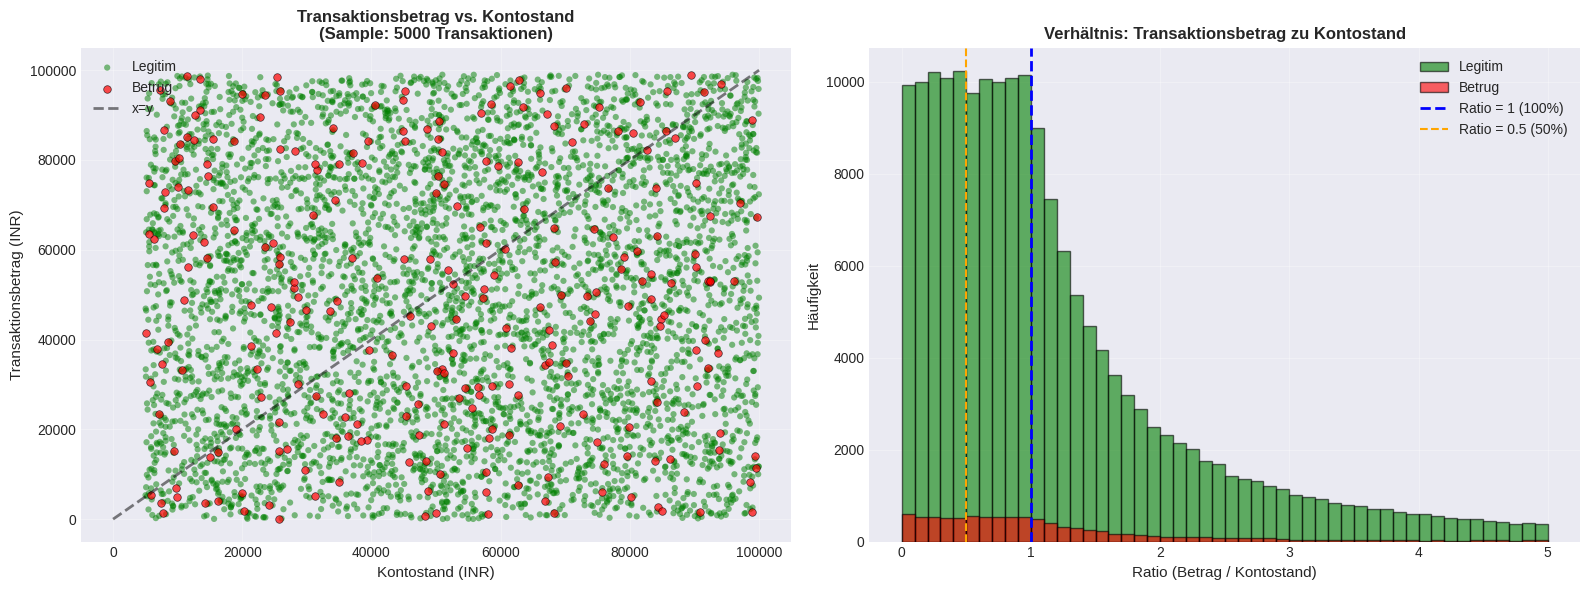

In [66]:
# Visualisierung: Transaktionsbetrag vs. Kontostand
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatterplot: Transaktionsbetrag vs. Kontostand (Sample für Performance)
sample_size = 5000
sample_df = df_loaded.sample(n=min(sample_size, len(df_loaded)), random_state=42)

# Legitime Transaktionen
legit_sample = sample_df[sample_df['Is_Fraud'] == 0]
fraud_sample = sample_df[sample_df['Is_Fraud'] == 1]

axes[0].scatter(legit_sample['Account_Balance'], legit_sample['Transaction_Amount'], 
                alpha=0.5, s=20, color='green', label='Legitim', edgecolors='none')
axes[0].scatter(fraud_sample['Account_Balance'], fraud_sample['Transaction_Amount'], 
                alpha=0.7, s=30, color='red', label='Betrug', edgecolors='black', linewidths=0.5)
axes[0].plot([0, 100000], [0, 100000], 'k--', alpha=0.5, linewidth=2, label='x=y')
axes[0].set_title('Transaktionsbetrag vs. Kontostand\n(Sample: 5000 Transaktionen)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kontostand (INR)', fontsize=11)
axes[0].set_ylabel('Transaktionsbetrag (INR)', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogramm: Verhältnis Transaktionsbetrag zu Kontostand
ratio_legit = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 0]['Amount_to_Balance_Ratio']
ratio_fraud = df_loaded_copy[df_loaded_copy['Is_Fraud'] == 1]['Amount_to_Balance_Ratio']

axes[1].hist(ratio_legit, bins=50, alpha=0.6, color='green', label='Legitim', edgecolor='black', range=(0, 5))
axes[1].hist(ratio_fraud, bins=50, alpha=0.6, color='red', label='Betrug', edgecolor='black', range=(0, 5))
axes[1].axvline(1, color='blue', linestyle='--', linewidth=2, label='Ratio = 1 (100%)')
axes[1].axvline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Ratio = 0.5 (50%)')
axes[1].set_title('Verhältnis: Transaktionsbetrag zu Kontostand', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ratio (Betrag / Kontostand)', fontsize=11)
axes[1].set_ylabel('Häufigkeit', fontsize=11)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Das Verhältnis von Transaktionsbetrag zu Kontostand zeigt interessante Muster. Etwa 73% der Transaktionen machen mehr als 50% des Kontostands aus, was auf häufige größere Transaktionen relativ zum verfügbaren Guthaben hindeutet. Dieses Verhältnis (Transaction_To_Balance_Ratio) wird im Feature Engineering als neues Feature erstellt, da ungewöhnlich hohe Transaktionen relativ zum Kontostand ein potentieller Betrugsindikator sein können. Der Scatterplot zeigt keine klare visuelle Trennung zwischen Betrugs- und legitimen Transaktionen.

In [67]:
# Analyse: Transaktionen pro Kunde
print("=" * 80)
print("TRANSAKTIONEN PRO KUNDE")
print("=" * 80)

transactions_per_customer = df_loaded.groupby('Customer_ID').size()

print(f"\nStatistiken:")
print(f"Mittelwert: {transactions_per_customer.mean():.2f} Transaktionen pro Kunde")
print(f"Median: {transactions_per_customer.median():.0f} Transaktionen pro Kunde")
print(f"Maximum: {transactions_per_customer.max()} Transaktionen")
print(f"Minimum: {transactions_per_customer.min()} Transaktion")

print(f"\nVerteilung:")
print(transactions_per_customer.value_counts().sort_index().head(10))

# Kunden mit den meisten Transaktionen
print(f"\nTop 10 Kunden mit den meisten Transaktionen:")
top_customers = transactions_per_customer.nlargest(10)
for idx, (customer_id, count) in enumerate(top_customers.items(), 1):
    fraud_count = df_loaded[df_loaded['Customer_ID'] == customer_id]['Is_Fraud'].sum()
    print(f"  {idx:2d}. {count:3d} Transaktionen (davon {fraud_count} Betrug)")

TRANSAKTIONEN PRO KUNDE

Statistiken:
Mittelwert: 1.00 Transaktionen pro Kunde
Median: 1 Transaktionen pro Kunde
Maximum: 1 Transaktionen
Minimum: 1 Transaktion

Verteilung:
1    200000
Name: count, dtype: int64

Top 10 Kunden mit den meisten Transaktionen:
   1.   1 Transaktionen (davon 0 Betrug)
   2.   1 Transaktionen (davon 0 Betrug)
   3.   1 Transaktionen (davon 0 Betrug)
   4.   1 Transaktionen (davon 0 Betrug)
   5.   1 Transaktionen (davon 0 Betrug)
   6.   1 Transaktionen (davon 0 Betrug)
   7.   1 Transaktionen (davon 0 Betrug)
   8.   1 Transaktionen (davon 0 Betrug)
   9.   1 Transaktionen (davon 0 Betrug)
  10.   1 Transaktionen (davon 0 Betrug)


In [68]:
# Merchant-Analyse
print("=" * 80)
print("MERCHANT-ANALYSE")
print("=" * 80)

print(f"\nAnzahl eindeutiger Merchants: {df_loaded['Merchant_ID'].nunique():,}")

# Transaktionen pro Merchant
transactions_per_merchant = df_loaded.groupby('Merchant_ID').size()
print(f"\nTransaktionen pro Merchant:")
print(f"Mittelwert: {transactions_per_merchant.mean():.2f}")
print(f"Median: {transactions_per_merchant.median():.0f}")
print(f"Maximum: {transactions_per_merchant.max()}")

# Merchants mit höchster Betrugsrate
merchant_fraud = df_loaded.groupby('Merchant_ID')['Is_Fraud'].agg(['sum', 'count', 'mean'])
merchant_fraud.columns = ['Betrug_Anzahl', 'Total', 'Betrug_Rate']
merchant_fraud['Betrug_Rate'] = merchant_fraud['Betrug_Rate'] * 100

# Nur Merchants mit mindestens 10 Transaktionen
merchant_fraud_filtered = merchant_fraud[merchant_fraud['Total'] >= 10].sort_values('Betrug_Rate', ascending=False)

print(f"\nTop 10 Merchants mit höchster Betrugsrate (mind. 10 Transaktionen):")
print(merchant_fraud_filtered.head(10).to_string())

MERCHANT-ANALYSE

Anzahl eindeutiger Merchants: 200,000

Transaktionen pro Merchant:
Mittelwert: 1.00
Median: 1
Maximum: 1

Top 10 Merchants mit höchster Betrugsrate (mind. 10 Transaktionen):
Empty DataFrame
Columns: [Betrug_Anzahl, Total, Betrug_Rate]
Index: []


## Zusammenfassung der explorativen Datenanalyse

**Datensatzstruktur:** Der Datensatz ist sauber (keine fehlenden Werte, keine Duplikate) mit einer guten Mischung aus numerischen und kategorialen Variablen. Auffällig ist, dass jeder Kunde nur eine Transaktion hat.

**Klassenungleichgewicht:** Mit einem Verhältnis von 18:1 (legitim zu Betrug) ist eine spezielle Behandlung beim Modelltraining erforderlich.

**Feature-Relevanz:** Numerische Features zeigen schwache Korrelationen zum Fraud-Label. Kategorische Features (insbesondere geografische) und das Verhältnis von Transaktionsbetrag zu Kontostand erscheinen vielversprechender für die Betrugserkennung.

---

# Teil 2: Datenvorverarbeitung

## 2.1 Daten laden

In [1]:
import pandas as pd

# Pfad zur PKL-Datei
pkl_file = '../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl'

# PKL-Datei einlesen
print(f"Lese PKL-Datei: {pkl_file}")
df_loaded = pd.read_pickle(pkl_file)
print(df_loaded.head())

Lese PKL-Datei: ../dataset_raw/Bank_Transaction_Fraud_Detection_raw.pkl
                            Customer_ID        Customer_Name  Gender  Age  \
0  d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e           Osha Tella    Male   60   
1  7c14ad51-781a-4db9-b7bd-67439c175262      Hredhaan Khosla  Female   51   
2  3a73a0e5-d4da-45aa-85f3-528413900a35       Ekani Nazareth    Male   20   
3  7902f4ef-9050-4a79-857d-9c2ea3181940  Yamini Ramachandran  Female   57   
4  3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9         Kritika Rege  Female   43   

         State                City                Bank_Branch Account_Type  \
0       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch      Savings   
1  Maharashtra              Nashik              Nashik Branch     Business   
2        Bihar           Bhagalpur           Bhagalpur Branch      Savings   
3   Tamil Nadu             Chennai             Chennai Branch     Business   
4       Punjab            Amritsar            Amritsar Branch      Savings 

In [7]:
# Bibliotheken für Visualisierungen importieren
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Bibliotheken für Hauptkompontenenanalyse importieren
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Visualisierungs-Bibliotheken geladen")

✓ Visualisierungs-Bibliotheken geladen


## 2.2 Fehlende Werte prüfen

In [8]:
# Fehlende Werte analysieren
print("=" * 80)
print("FEHLENDE WERTE")
print("=" * 80)
missing_values = df_loaded.isnull().sum()
na_values = df_loaded.isna().sum()

print("Missing null values in the dataset:")
print(missing_values)
print("=" * 80)
print("Missing N/A values in the dataset:")
print(df_loaded.isna().sum())

print("=" * 80)
print("Result:")
# Prüfen, ob überhaupt fehlende Werte vorhanden sind:
if missing_values.sum() == 0 and na_values.sum() == 0:
    print("✅ no missing values in the dataset!")
else:
    print("⚠️ missing values!!!")


FEHLENDE WERTE
Missing null values in the dataset:
Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64
Missing N/A values in the dataset:
Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Ac

Wie bereits in der EDA festgestellt, enthält der Datensatz keine fehlenden Werte. Die explizite Prüfung auf sowohl null als auch NaN-Werte bestätigt die Datenqualität. Eine Imputation-Strategie ist somit nicht erforderlich, und die Vorverarbeitung kann direkt mit der Feature-Auswahl und dem Encoding fortfahren.

## 2.3 Irrelevante Spalten entfernen

In [9]:
analyzeDf = pd.DataFrame(index = list(df_loaded))
analyzeDf['type'] = df_loaded.dtypes
analyzeDf['count'] = df_loaded.count()
analyzeDf['nunique'] = df_loaded.nunique()
analyzeDf['%unique'] = analyzeDf['nunique'] /len(df_loaded) * 100
print(analyzeDf)

                            type   count  nunique   %unique
Customer_ID               object  200000   200000  100.0000
Customer_Name             object  200000   142699   71.3495
Gender                    object  200000        2    0.0010
Age                        int64  200000       53    0.0265
State                     object  200000       34    0.0170
City                      object  200000      145    0.0725
Bank_Branch               object  200000      145    0.0725
Account_Type              object  200000        3    0.0015
Transaction_ID            object  200000   200000  100.0000
Transaction_Date          object  200000       31    0.0155
Transaction_Time          object  200000    77856   38.9280
Transaction_Amount       float64  200000   197978   98.9890
Merchant_ID               object  200000   200000  100.0000
Transaction_Type          object  200000        5    0.0025
Merchant_Category         object  200000        6    0.0030
Account_Balance          float64  200000

In [10]:
# Dropping columns with one unique value
single_value_columns = [col for col in df_loaded.columns if df_loaded[col].nunique() == 1]
print("Columns with only one unique value:", single_value_columns)
df_loaded = df_loaded.drop(columns=single_value_columns)

# Dropping columns with only unique value
max_value = df_loaded['Customer_ID'].count()
max_value_columns = [col for col in df_loaded.columns if df_loaded[col].nunique() == max_value]
print("=" * 80)
print("Columns with only one unique value:", max_value_columns)
df_loaded = df_loaded.drop(columns=max_value_columns)

Columns with only one unique value: ['Transaction_Currency']
Columns with only one unique value: ['Customer_ID', 'Transaction_ID', 'Merchant_ID']


Spalten ohne Varianz (nur ein eindeutiger Wert) sowie Spalten mit ausschließlich eindeutigen Werten (wie Transaction_ID, Customer_ID) werden entfernt. Diese Features tragen nicht zur Vorhersage bei. Konstante Spalten liefern keine Information, und ID-Spalten würden zu Overfitting führen, da das Modell Vorhersagen an spezifische IDs koppeln würde statt Muster zu lernen. Zusätzlich wurden personenbezogene Daten (Name, E-Mail, Telefon) entfernt, da diese irrelevant für die Betrugserkennung sind und datenschutzrechtliche Bedenken aufwerfen.

In [11]:
# Dropping columns which are not relevant for the fraud detection
columns_unrelevant = ['Customer_Email', 'Customer_Contact', 'Customer_Name']
df_loaded = df_loaded.drop(columns=columns_unrelevant)

In [12]:
# Checking columns after dropping one unique columns
df_loaded.columns

Index(['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type',
       'Transaction_Date', 'Transaction_Time', 'Transaction_Amount',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Description'],
      dtype='object')

In [13]:
# Checking if similar sounding columns are identical
print((df_loaded["Device_Type"] == df_loaded["Transaction_Device"]).all())

False


## 2.4 Feature Engineering: Zeit-Features

In [14]:
# Extract new features from Date and Time
df_loaded['Transaction_Date'] = pd.to_datetime(df_loaded['Transaction_Date'], format='%d-%m-%Y')
df_loaded['Transaction_Time'] = pd.to_datetime(df_loaded['Transaction_Time'], format='%H:%M:%S')

df_loaded['Transaction_Day'] = df_loaded['Transaction_Date'].dt.day
df_loaded['Transaction_Month'] = df_loaded['Transaction_Date'].dt.month
df_loaded['Transaction_Year'] = df_loaded['Transaction_Date'].dt.year 
df_loaded['Transaction_Hour'] = df_loaded['Transaction_Time'].dt.hour
df_loaded['Transaction_Minute'] = df_loaded['Transaction_Time'].dt.minute
df_loaded['Transaction_Second'] = df_loaded['Transaction_Time'].dt.second

# Dropping columns with one unique value e.g. year, month
single_value = [col for col in df_loaded.columns if df_loaded[col].nunique() == 1]
df_loaded = df_loaded.drop(columns=single_value)

# Drop 'Transaction_Date' and 'Transaction_Time' columns after feature extraction
df_loaded = df_loaded.drop(columns=['Transaction_Date', 'Transaction_Time'])

Aus den Datums- und Zeitangaben werden granulare zeitliche Features extrahiert. Transaction_Day, Transaction_Hour, Transaction_Minute und Transaction_Second. Jahr und Monat werden nach der Extraktion wieder entfernt, da diese im Datensatz nur jeweils einen Wert aufweisen (Januar 2025). Die ursprünglichen Datetime-Spalten werden nach erfolgreicher Feature-Extraktion gelöscht. Diese Transformation ermöglicht es dem Modell, zeitliche Muster zu erkennen, etwa ob bestimmte Uhrzeiten oder Tage im Monat mit erhöhtem Betrugsrisiko verbunden sind.

## 2.5 Feature Engineering: Berechnete Features

In [15]:
# new Feature: Ration between Account_Balance before the transaction and the transaction_amount
df_loaded['Transaction_To_Balance_Ratio'] = df_loaded['Transaction_Amount'] / (df_loaded['Account_Balance']+df_loaded['Transaction_Amount'] )

# flag for large transaction: transaction_amount is above 95% of the other transaction amouts
threshold = df_loaded['Transaction_Amount'].quantile(0.95)
df_loaded['Is_Large_Transaction']= (df_loaded['Transaction_Amount'] > threshold).astype(int)

print(df_loaded.head())

   Gender  Age        State                City                Bank_Branch  \
0    Male   60       Kerala  Thiruvananthapuram  Thiruvananthapuram Branch   
1  Female   51  Maharashtra              Nashik              Nashik Branch   
2    Male   20        Bihar           Bhagalpur           Bhagalpur Branch   
3  Female   57   Tamil Nadu             Chennai             Chennai Branch   
4  Female   43       Punjab            Amritsar            Amritsar Branch   

  Account_Type  Transaction_Amount Transaction_Type Merchant_Category  \
0      Savings            32415.45         Transfer        Restaurant   
1     Business            43622.60     Bill Payment        Restaurant   
2      Savings            63062.56     Bill Payment         Groceries   
3     Business            14000.72            Debit     Entertainment   
4      Savings            18335.16         Transfer     Entertainment   

   Account_Balance  ...        Transaction_Location Device_Type Is_Fraud  \
0         74557.

Zwei neue berechnete Features werden dem Datensatz hinzugefügt. Das Transaction_To_Balance_Ratio berechnet das Verhältnis des Transaktionsbetrags zum rekonstruierten Kontostand vor der Transaktion und kann ungewöhnlich hohe Transaktionen relativ zum verfügbaren Guthaben identifizieren. Das Is_Large_Transaction Flag markiert binär alle Transaktionen, die über dem 95. Perzentil aller Transaktionsbeträge liegen. Beide Features zielen darauf ab, Anomalien im Transaktionsverhalten zu erfassen, die auf Betrug hindeuten könnten.

## 2.6 Encoding kategorischer Features

### Variante A: One-Hot-Encoding

In [16]:
# Encode non-numerical columns
#  Numerische und kategorische Spalten erkennen
categorical_cols = df_loaded.select_dtypes(include=["object", "category"]).columns
numeric_cols = df_loaded.select_dtypes(include=["number"]).columns

#  One-Hot-Encoding für die kategorischen Spalten
df_encoded_oneHot = pd.get_dummies(df_loaded, columns=categorical_cols, drop_first=True)

print(df_encoded_oneHot.head())


   Age  Transaction_Amount  Account_Balance  Is_Fraud  Transaction_Day  \
0   60            32415.45         74557.27         0               23   
1   51            43622.60         74622.66         0               11   
2   20            63062.56         66817.99         0               25   
3   57            14000.72         58177.08         0               19   
4   43            18335.16         16108.56         0               30   

   Transaction_Hour  Transaction_Minute  Transaction_Second  \
0                16                   4                   7   
1                17                  14                  53   
2                 3                   9                  52   
3                12                  27                   2   
4                18                  30                  46   

   Transaction_To_Balance_Ratio  Is_Large_Transaction  ...  \
0                      0.303025                     0  ...   
1                      0.368916                     

### Variante B: Label-Encoding (gewählt)

In [17]:
# Label-Encoding für alle kategorischen Spalten
df_encoded = df_loaded.copy()
categorical_cols = df_encoded.select_dtypes(include=["object", "category"]).columns

le_dict = {}  # Speichert die Encoder pro Spalte
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

print("=== Label-encodierte Tabelle ===")
print(df_encoded.head())


=== Label-encodierte Tabelle ===
   Gender  Age  State  City  Bank_Branch  Account_Type  Transaction_Amount  \
0       1   60     15   127          127             2            32415.45   
1       0   51     18   100          100             0            43622.60   
2       1   20      4    13           13             2            63062.56   
3       0   57     28    22           22             0            14000.72   
4       0   43     25     7            7             2            18335.16   

   Transaction_Type  Merchant_Category  Account_Balance  ...  \
0                 3                  5         74557.27  ...   
1                 0                  5         74622.66  ...   
2                 0                  3         66817.99  ...   
3                 2                  2         58177.08  ...   
4                 3                  2         16108.56  ...   

   Transaction_Location  Device_Type  Is_Fraud  Transaction_Description  \
0                   129            3  

Für die kategorischen Variablen werden zwei Encoding-Strategien implementiert und verglichen. One-Hot-Encoding erstellt für jede Kategorie eine binäre Spalte, was die Dimensionalität stark erhöht (besonders bei Features wie City mit vielen eindeutigen Werten). Label-Encoding weist jeder Kategorie eine numerische ID zu und behält die ursprüngliche Spaltenzahl bei. Für die weitere Analyse wird Label-Encoding gewählt, da es speichereffizienter ist und bei der nachfolgenden PCA-Analyse vergleichbare Ergebnisse liefert.

## 2.7 Hauptkomponentenanalyse (PCA)

In [18]:
def run_pca(df, n_components=2, df_name="DataFrame"):
    """
    Führt PCA auf einem DataFrame aus, standardisiert die Daten und gibt Ergebnisse zurück.
    """
    # Standardisieren
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    # PCA durchführen
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(X_scaled)

    # DataFrame für PCA-Komponenten
    pca_df = pd.DataFrame(principal_components, columns=[f"PC{i+1}" for i in range(n_components)])

    # Loadings
    loadings = pd.DataFrame(pca.components_.T, 
                            index=df.columns, 
                            columns=[f"PC{i+1}" for i in range(n_components)])
    
    # Ergebnisse ausgeben
    print(f"\n=== PCA-Ergebnisse für {df_name} (erste 5 Zeilen) ===")
    print(pca_df.head())
    
    print(f"\n=== Erklärte Varianz pro Komponente ({df_name}) ===")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"PC{i+1}: {var:.2%}")

    print(f"\n=== Feature-Gewichte pro Hauptkomponente ({df_name}) ===")
    print(loadings.sort_values(by="PC1", ascending=False))
    
    return pca_df, loadings, pca.explained_variance_ratio_


# Beispiel: Zwei DataFrames nebeneinander vergleichen
pca_df1, loadings1, var_ratio1 = run_pca(df_encoded, df_name="df_encoded_label_encoding")
pca_df2, loadings2, var_ratio2 = run_pca(df_encoded_oneHot, df_name="df_encoded_oneHot_encoding")

# Nebeneinander darstellen (erste 5 Zeilen)
combined_pca = pd.concat([pca_df1.add_suffix('_df1'), pca_df2.add_suffix('_df2')], axis=1)
print("\n=== PCA-Komponenten nebeneinander ===")
print(combined_pca.head())


=== PCA-Ergebnisse für df_encoded_label_encoding (erste 5 Zeilen) ===
        PC1       PC2
0  2.302197 -1.269831
1  1.174214 -0.821616
2 -2.336561  0.059422
3 -2.083256 -1.654892
4 -2.670977  0.011724

=== Erklärte Varianz pro Komponente (df_encoded_label_encoding) ===
PC1: 14.30%
PC2: 9.84%

=== Feature-Gewichte pro Hauptkomponente (df_encoded_label_encoding) ===
                                   PC1       PC2
City                          0.576811 -0.009482
Bank_Branch                   0.576811 -0.009482
Transaction_Location          0.576776 -0.009488
Transaction_To_Balance_Ratio  0.010756  0.659274
Transaction_Amount            0.009823  0.564373
Account_Type                  0.006261 -0.004772
Is_Large_Transaction          0.005800  0.324289
Transaction_Minute            0.003196 -0.001799
Is_Fraud                      0.002265 -0.003799
Transaction_Day               0.001916 -0.001823
Transaction_Description       0.001283 -0.003218
Transaction_Hour              0.000556  0.0


=== PCA-Ergebnisse für df_encoded_oneHot_encoding (erste 5 Zeilen) ===
        PC1       PC2
0 -0.318074 -0.675543
1 -0.337801 -0.768565
2 -0.346599 -0.675759
3 -0.332765 -0.726692
4 -0.803688  5.575500

=== Erklärte Varianz pro Komponente (df_encoded_oneHot_encoding) ===
PC1: 0.60%
PC2: 0.60%

=== Feature-Gewichte pro Hauptkomponente (df_encoded_oneHot_encoding) ===
                                                  PC1       PC2
Transaction_Location_Kavaratti, Lakshadweep  0.490415  0.040965
Bank_Branch_Kavaratti Branch                 0.490415  0.040965
State_Lakshadweep                            0.490415  0.040965
City_Kavaratti                               0.490415  0.040965
Transaction_Description_Credit card payment  0.004613 -0.000602
...                                               ...       ...
State_Punjab                                -0.035314  0.249227
State_Chandigarh                            -0.043950  0.316036
Transaction_Location_Chandigarh, Chandigarh -0.043950

Die Hauptkomponentenanalyse (PCA) wird auf beide Encoding-Varianten angewendet, um die Dimensionsreduktion zu evaluieren. Die erklärte Varianz pro Komponente zeigt, wie viel Information in den reduzierten Dimensionen erhalten bleibt. Die Feature-Gewichte (Loadings) identifizieren, welche ursprünglichen Features am stärksten zu den Hauptkomponenten beitragen. Der Vergleich zeigt, dass beide Encoding-Strategien ähnliche Ergebnisse in Bezug auf die Varianzaufklärung liefern, wobei Label-Encoding die kompaktere Darstellung bietet.

## 2.8 Korrelationsanalyse


=== Korrelationsmatrix der label-encodierten Features ===
                                Gender       Age     State      City  \
Gender                        1.000000  0.001692  0.002899 -0.000299   
Age                           0.001692  1.000000 -0.004638 -0.002284   
State                         0.002899 -0.004638  1.000000 -0.046278   
City                         -0.000299 -0.002284 -0.046278  1.000000   
Bank_Branch                  -0.000299 -0.002284 -0.046278  1.000000   
Account_Type                  0.001260 -0.000281 -0.002314  0.007245   
Transaction_Amount            0.001468 -0.003087  0.002480  0.005674   
Transaction_Type              0.001339 -0.001291 -0.000130  0.000101   
Merchant_Category             0.002233 -0.000381  0.001078 -0.001047   
Account_Balance              -0.000392  0.000269  0.000136 -0.002628   
Transaction_Device            0.002109  0.002429  0.001103 -0.001441   
Transaction_Location         -0.000261 -0.002291 -0.044936  0.999910   
Devic

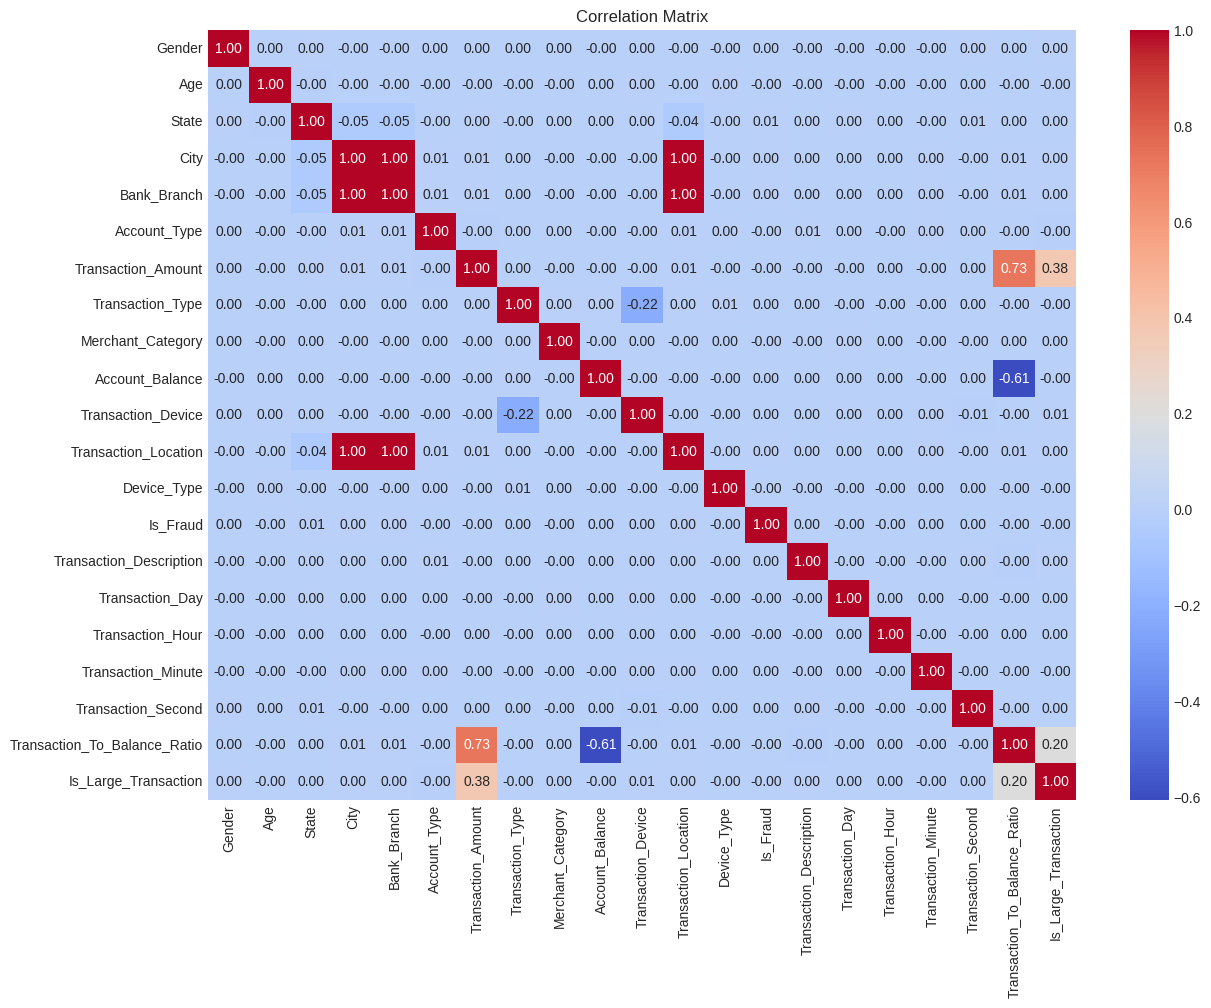

In [19]:
# Korrelationsmatrix der label-encodierten Features
corr_matrix = df_encoded.corr()
print("\n=== Korrelationsmatrix der label-encodierten Features ===")
print(corr_matrix)

# Heatmap visualisieren
plt.figure(figsize=(14, 10))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

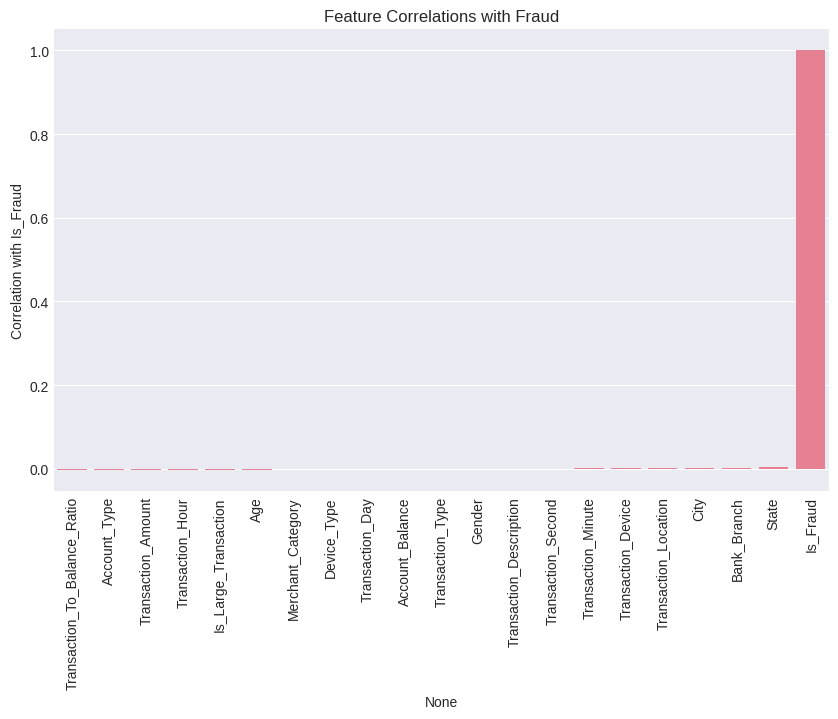

In [20]:
corr = df_encoded.corr()['Is_Fraud'].sort_values(ascending=False)
corr = corr.sort_values() 

plt.figure(figsize=(10,6))
sns.barplot(x=corr.index, y=corr.values)
plt.xticks(rotation=90)
plt.ylabel('Correlation with Is_Fraud')
plt.title('Feature Correlations with Fraud')
plt.show()

Die Korrelationsanalyse der label-encodierten Features bestätigt die Erkenntnisse aus der EDA. Die meisten Features weisen nur schwache Korrelationen mit dem Fraud-Label auf. Die Heatmap visualisiert auch Korrelationen zwischen den Features untereinander, was für die Identifikation redundanter Features nützlich ist. Das Balkendiagramm sortiert alle Features nach ihrer Korrelation mit Is_Fraud und zeigt, dass selbst die stärksten Korrelationen moderat bleiben. Dies unterstreicht die Notwendigkeit nicht-linearer Modelle für die Betrugserkennung.

## 2.9 Vorverarbeitete Daten speichern

In [21]:
output_file = "daten_vorverarbeitet.pkl"
df_loaded.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

output_file = "daten_vorverarbeitet_encoded.pkl"
df_encoded.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

Neue Datei gespeichert als: daten_vorverarbeitet.pkl
Neue Datei gespeichert als: daten_vorverarbeitet_encoded.pkl


## Zusammenfassung der Vorverarbeitung

**Durchgeführte Schritte:** Fehlende Werte geprüft (keine vorhanden), irrelevante Spalten entfernt (IDs, konstante Werte, personenbezogene Daten), Zeit-Features extrahiert, zwei neue berechnete Features erstellt (Transaction_To_Balance_Ratio, Is_Large_Transaction), Label-Encoding für kategorische Features angewendet.

**Entscheidung Encoding:** Label-Encoding wurde gewählt, da es kompakter ist als One-Hot-Encoding und bei der PCA-Analyse vergleichbare Ergebnisse liefert.

---

# Teil 3: Datenteilung

## 3.1 Vorverarbeitete Daten laden

In [1]:
import pandas as pd

# Pfad zur PKL-Datei
pkl_file = '../2. Datenvorverarbeitung/daten_vorverarbeitet_encoded.pkl'

# PKL-Datei einlesen
print(f"Lese PKL-Datei: {pkl_file}")
df_loaded = pd.read_pickle(pkl_file)

Lese PKL-Datei: ../2. Datenvorverarbeitung/daten_vorverarbeitet_encoded.pkl


## 3.2 Stratifizierte Datenteilung

In [2]:
from sklearn.model_selection import train_test_split

#(Train 70%, Temp 30%) - used stratify to ensure an equal distribution of fraud cases across the sets
train, temp = train_test_split(df_loaded, test_size=0.3, random_state=42, stratify=df_loaded['Is_Fraud'])

#(Test 15%, Validation 15%)
validation, test = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['Is_Fraud'])

Die Daten werden im Verhältnis 70/15/15 in Trainings-, Validierungs- und Testdaten aufgeteilt. Der stratify-Parameter bei train_test_split stellt sicher, dass das Klassenverhältnis (Fraud-Rate von ca. 5.5%) in allen drei Teilmengen identisch bleibt. Dies ist bei unbalancierten Datensätzen essentiell, um repräsentative Teilmengen zu erhalten und zu verhindern, dass beispielsweise die Testdaten zufällig überproportional viele oder wenige Betrugsfälle enthalten.

## 3.3 Splits speichern

In [3]:
output_file = "train.pkl"
train.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

output_file = "test.pkl"
test.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

output_file = "validation.pkl"
validation.to_pickle(output_file)
print(f"Neue Datei gespeichert als: {output_file}")

Neue Datei gespeichert als: train.pkl
Neue Datei gespeichert als: test.pkl
Neue Datei gespeichert als: validation.pkl


In [4]:
print("=" * 30)
print("Training:")
print(len(train))
print("=" * 30)
print("Testing:")
print(len(test))
print("=" * 30)
print("Validation:")
print(len(validation))

Training:
140000
Testing:
30000
Validation:
30000


Die drei Datensätze werden als separate Pickle-Dateien gespeichert (train.pkl, validation.pkl, test.pkl). Die Größenverteilung entspricht dem gewünschten 70/15/15-Verhältnis. Die Speicherung als Pickle-Format erhält die Datentypen und ermöglicht ein schnelles Laden in nachfolgenden Notebooks ohne erneute Vorverarbeitung.

# Teil 4: Modelltraining

## 4.1 Setup und Bibliotheken

In [ ]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import plot_model

import keras_tuner as kt

try:
    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
except ImportError:
    raise ImportError("scikit-learn muss installiert sein.")

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# Plotting-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU verfügbar: {tf.config.list_physical_devices('GPU')}")
print("Bibliotheken geladen")

import os
os.environ['PYTHONHASHSEED']=str(42)

/home/enzoz/Hochschule/QKI/GIT/fraudDetection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-13 19:19:26.218460: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 19:19:26.243620: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 19:19:28.206999: I tensorflow/core/util/port.cc:153] one

TensorFlow Version: 2.20.0
GPU verfügbar: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Bibliotheken geladen


W0000 00:00:1763057968.900453 2319903 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1763057968.906508 2319903 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
# GPU komplett deaktivieren (CUDA-Fehler beheben)
print("Deaktiviere GPU und erzwinge CPU-Nutzung...")

# GPU komplett unsichtbar machen für TensorFlow
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Alternative: TensorFlow konfigurieren, keine GPU zu verwenden
tf.config.set_visible_devices([], 'GPU')

print("GPU deaktiviert - verwende nur CPU")
print("Das Training wird langsamer sein, aber stabil laufen")

# Verfügbare Devices anzeigen
print(f"\nVerfügbare Devices: {tf.config.list_physical_devices()}")

Deaktiviere GPU und erzwinge CPU-Nutzung...
GPU deaktiviert - verwende nur CPU
Das Training wird langsamer sein, aber stabil laufen

Verfügbare Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# Trainingsdaten laden
train_df = pd.read_pickle('../3. Datenteilung/train.pkl')
validation_df = pd.read_pickle('../3. Datenteilung/validation.pkl')
test_df = pd.read_pickle('../3. Datenteilung/test.pkl')

print("Daten geladen:")
print(f"Training: {train_df.shape}")
print(f"Validation: {validation_df.shape}")
print(f"Test: {test_df.shape}")

# Fraud-Verteilung prüfen
print(f"\nFraud-Verteilung Training:")
print(train_df['Is_Fraud'].value_counts())
print(f"\nFraud-Rate: {train_df['Is_Fraud'].mean()*100:.2f}%")

Daten geladen:
Training: (140000, 21)
Validation: (30000, 21)
Test: (30000, 21)

Fraud-Verteilung Training:
Is_Fraud
0    132938
1      7062
Name: count, dtype: int64

Fraud-Rate: 5.04%


In [4]:
# Features und Labels trennen
X_train = train_df.drop('Is_Fraud', axis=1)
y_train = train_df['Is_Fraud']

X_val = validation_df.drop('Is_Fraud', axis=1)
y_val = validation_df['Is_Fraud']

X_test = test_df.drop('Is_Fraud', axis=1)
y_test = test_df['Is_Fraud']

print(f"Feature-Anzahl: {X_train.shape[1]}")
print(f"\nFeatures: {list(X_train.columns)}")

Feature-Anzahl: 20

Features: ['Gender', 'Age', 'State', 'City', 'Bank_Branch', 'Account_Type', 'Transaction_Amount', 'Transaction_Type', 'Merchant_Category', 'Account_Balance', 'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Transaction_Description', 'Transaction_Day', 'Transaction_Hour', 'Transaction_Minute', 'Transaction_Second', 'Transaction_To_Balance_Ratio', 'Is_Large_Transaction']


In [5]:
# Feature-Normalisierung (wichtig für NN)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features standardisiert")
print(f"Mittelwert: {X_train_scaled.mean():.6f}")
print(f"Standardabweichung: {X_train_scaled.std():.6f}")

Features standardisiert
Mittelwert: 0.000000
Standardabweichung: 1.000000


Die Features werden mit StandardScaler standardisiert, sodass jedes Feature einen Mittelwert nahe 0 und eine Standardabweichung nahe 1 aufweist. Diese Normalisierung ist für neuronale Netze essentiell, da sie die Konvergenz des Gradientenabstiegs verbessert und verhindert, dass Features mit größeren Wertebereichen das Training dominieren. Der Scaler wird nur auf den Trainingsdaten gefittet und dann auf Validierungs- und Testdaten angewendet, um Data Leakage zu vermeiden.

## 4.2 Umgang mit Klassenungleichgewicht

Zwei Ansätze werden verglichen: Class Weights (Gewichtung in der Loss-Funktion) und SMOTE (synthetische Oversampling-Methode).

In [6]:
# Workflow A: Class Weights berechnen
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("=" * 80)
print("WORKFLOW A: CLASS WEIGHTS")
print("=" * 80)
print(f"Legitim (0): {class_weight_dict[0]:.2f}")
print(f"Betrug (1): {class_weight_dict[1]:.2f}")
print(f"Ratio: {class_weight_dict[1]/class_weight_dict[0]:.2f}:1")
print(f"Trainingsdaten: {X_train_scaled.shape}")

WORKFLOW A: CLASS WEIGHTS
Legitim (0): 0.53
Betrug (1): 9.91
Ratio: 18.82:1
Trainingsdaten: (140000, 20)


Die Class Weights werden automatisch mit der Option 'balanced' berechnet. Die Betrugsklasse erhält ein Gewicht von etwa 9 (entsprechend dem inversen Klassenverhältnis), während die legitime Klasse ein Gewicht nahe 0.5 erhält. Durch diese Gewichtung in der Loss-Funktion wird jede Fehlklassifikation eines Betrugsfalls etwa 18-mal stärker bestraft als eine Fehlklassifikation einer legitimen Transaktion. Dies zwingt das Modell, besonderes Augenmerk auf die korrekte Erkennung der Minderheitsklasse zu legen.

## 4.3 Workflow A: Training mit Class Weights

### Baseline-Modell Definition

In [7]:
def create_baseline_model(input_dim, learning_rate=0.001):
    """
    Einfaches Baseline-Modell
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

# Modell erstellen und anzeigen
baseline_model = create_baseline_model(X_train_scaled.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

Das Baseline-Modell implementiert eine klassische Feedforward-Architektur mit zwei versteckten Schichten (64 und 32 Neuronen). Die ReLU-Aktivierungsfunktion ermöglicht das Lernen nicht-linearer Muster. Dropout-Layer mit einer Rate von 30% dienen der Regularisierung und reduzieren Overfitting, indem sie während des Trainings zufällig Neuronen deaktivieren. Die Ausgabeschicht verwendet Sigmoid-Aktivierung für die binäre Klassifikation, wobei der Output als Wahrscheinlichkeit für Betrug interpretiert wird.

In [8]:
# Callbacks definieren
early_stopping = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=15,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    'baseline_model_best.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Callbacks definiert")

Callbacks definiert


In [9]:
# Baseline-Modell trainieren (OHNE SMOTE, mit Class Weights)
print("=" * 80)
print("WORKFLOW A: Training Baseline-Modell mit Class Weights")
print("=" * 80)
print()

history_baseline_cw = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1,
)

print("\nTraining abgeschlossen")

WORKFLOW A: Training Baseline-Modell mit Class Weights

Epoch 1/100


2025-11-13 19:19:29.489037: I external/local_xla/xla/service/service.cc:163] XLA service 0x76da1800cd80 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 19:19:29.489050: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 19:19:29.507322: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


397/547 ━━━━━━━━━━━━━━━━━━━━ 0s 380us/step - accuracy: 0.5290 - auc: 0.4981 - loss: 0.7249 - precision: 0.0505 - recall: 0.4701

I0000 00:00:1763057969.755284 2320042 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.5242 - auc: 0.4991 - loss: 0.7203 - precision: 0.0505 - recall: 0.4762
Epoch 1: val_auc improved from None to 0.50707, saving model to baseline_model_best.h5

Epoch 1: val_auc improved from None to 0.50707, saving model to baseline_model_best.h5


...

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.4428 - auc: 0.5057 - loss: 0.6936 - precision: 0.0509 - recall: 0.5694 - val_accuracy: 0.3685 - val_auc: 0.5108 - val_loss: 0.6956 - val_precision: 0.0517 - val_recall: 0.6642 - learning_rate: 0.0010
Epoch 5/100
Epoch 5/100
496/547 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - accuracy: 0.4811 - auc: 0.5193 - loss: 0.6961 - precision: 0.0529 - recall: 0.5430
Epoch 5: val_auc improved from 0.51079 to 0.51110, saving model to baseline_model_best.h5

Epoch 5: val_auc improved from 0.51079 to 0.51110, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - accuracy: 0.4594 - auc: 0.5160 - loss: 0.6928 - precision: 0.0520 - recall: 0.5641 - val_accuracy: 0.5164 - val_auc: 0.5111 - val_loss: 0.6901 - val_precision: 0.0514 - val_recall: 0.4924 - learning_rate: 0.0010
Epoch 6/100
Epoch 6/100
518/547 ━━━━━━━━━━━━━━━━━━━━ 0s 389us/step - accuracy: 0.5302 - auc: 0.5121 - loss: 0.6898 - precision: 0.0524 - recall: 0.4910
Epoch 6: val_auc improved from 0.51110 to 0.51394, saving model to baseline_model_best.h5

Epoch 6: val_auc improved from 0.51110 to 0.51394, saving model to baseline_model_best.h5


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - accuracy: 0.4493 - auc: 0.5127 - loss: 0.6928 - precision: 0.0522 - recall: 0.5786 - val_accuracy: 0.3718 - val_auc: 0.5139 - val_loss: 0.6963 - val_precision: 0.0522 - val_recall: 0.6682 - learning_rate: 0.0010
Epoch 7/100
Epoch 7/100
519/547 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.5039 - auc: 0.5167 - loss: 0.6891 - precision: 0.0518 - recall: 0.5165
Epoch 7: val_auc did not improve from 0.51394
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.4611 - auc: 0.5147 - loss: 0.6929 - precision: 0.0521 - recall: 0.5629 - val_accuracy: 0.3804 - val_auc: 0.5103 - val_loss: 0.6966 - val_precision: 0.0516 - val_recall: 0.6497 - learning_rate: 0.0010
Epoch 8/100

Epoch 7: val_auc did not improve from 0.51394
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.4611 - auc: 0.5147 - loss: 0.6929 - precision: 0.0521 - recall: 0.5629 - val_accuracy: 0.3804 - val_auc: 0.5103 - val_loss: 0.6966 - val_precision: 0.0516 - val_recall: 0.6

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.4419 - auc: 0.5159 - loss: 0.6927 - precision: 0.0524 - recall: 0.5895 - val_accuracy: 0.4450 - val_auc: 0.5158 - val_loss: 0.6945 - val_precision: 0.0521 - val_recall: 0.5823 - learning_rate: 0.0010
Epoch 9/100
Epoch 9/100
519/547 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.5207 - auc: 0.5305 - loss: 0.6891 - precision: 0.0540 - recall: 0.5180
Epoch 9: val_auc did not improve from 0.51576
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.5058 - auc: 0.5283 - loss: 0.6916 - precision: 0.0539 - recall: 0.5319 - val_accuracy: 0.4412 - val_auc: 0.5096 - val_loss: 0.6913 - val_precision: 0.0514 - val_recall: 0.5777 - learning_rate: 0.0010
Epoch 10/100

Epoch 9: val_auc did not improve from 0.51576
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 499us/step - accuracy: 0.5058 - auc: 0.5283 - loss: 0.6916 - precision: 0.0539 - recall: 0.5319 - val_accuracy: 0.4412 - val_auc: 0.5096 - val_loss: 0.6913 - val_precision: 0.0514 - val_recall: 0.

547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 504us/step - accuracy: 0.4896 - auc: 0.5477 - loss: 0.6898 - precision: 0.0565 - recall: 0.5803 - val_accuracy: 0.3714 - val_auc: 0.5163 - val_loss: 0.7005 - val_precision: 0.0513 - val_recall: 0.6550 - learning_rate: 2.5000e-04
Epoch 18/100
Epoch 18/100
509/547 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - accuracy: 0.4528 - auc: 0.5426 - loss: 0.6972 - precision: 0.0567 - recall: 0.6142
Epoch 18: val_auc did not improve from 0.51628
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.4628 - auc: 0.5457 - loss: 0.6893 - precision: 0.0559 - recall: 0.6071 - val_accuracy: 0.4020 - val_auc: 0.5131 - val_loss: 0.6980 - val_precision: 0.0513 - val_recall: 0.6206 - learning_rate: 2.5000e-04
Epoch 19/100

Epoch 18: val_auc did not improve from 0.51628
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.4628 - auc: 0.5457 - loss: 0.6893 - precision: 0.0559 - recall: 0.6071 - val_accuracy: 0.4020 - val_auc: 0.5131 - val_loss: 0.6980 - val_precision: 0.0513 - va

Das Training mit Class Weights wurde mit drei Callbacks durchgeführt: EarlyStopping stoppt das Training, wenn sich die Validierungs-AUC 15 Epochen lang nicht verbessert und stellt die besten Gewichte wieder her. ReduceLROnPlateau halbiert die Lernrate bei stagnierendem Validierungs-Loss. ModelCheckpoint speichert das beste Modell basierend auf der Validierungs-AUC. Diese Kombination verhindert Overfitting und ermöglicht adaptive Lernratenanpassung.

### Model Evaluation

In [11]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Gibt nur Accuracy (gesamt) und Recall der Betrugsklasse (Label=1) aus.
    """
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int).ravel()

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_test, y_pred)
    recall_fraud = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    print("=" * 80)
    print(f"EVALUATION: {model_name}")
    print("=" * 80)
    print(f"Recall (Fraud-Klasse = 1): {recall_fraud:.4f}")

    return {
        'accuracy': accuracy,
        'recall_fraud': recall_fraud
    }

# Baseline-Modell evaluieren (Class Weights)
baseline_cw_results = evaluate_model(baseline_model, X_test_scaled, y_test, "Workflow A - Baseline (Class Weights)")


EVALUATION: Workflow A - Baseline (Class Weights)
Recall (Fraud-Klasse = 1): 0.6186


Der Recall der Fraud-Klasse ist die zentrale Metrik für die Betrugserkennung, da er angibt, welcher Anteil der tatsächlichen Betrugsfälle korrekt erkannt wird. Ein Recall von ca. 62 % bedeutet, dass 62 % aller Betrugsfälle gefunden werden, während 38 % unentdeckt bleiben (False Negatives). In der Praxis ist ein hoher Recall besonders wichtig, da übersehene Betrugsfälle direkte finanzielle Verluste verursachen.

## 4.4 Workflow B: Training mit SMOTE

### SMOTE anwenden

In [15]:
# SMOTE auf Trainingsdaten anwenden
print("=" * 80)
print("WORKFLOW B: Anwendung von SMOTE")
print("=" * 80)
print()

print("Original Trainingsdaten:")
print(f"  Klasse 0 (Legitim): {sum(y_train == 0):,}")
print(f"  Klasse 1 (Fraud): {sum(y_train == 1):,}")
print(f"  Verhältnis: {sum(y_train == 0) / sum(y_train == 1):.2f}:1")

# SMOTE mit sampling_strategy=0.5 (Ziel: Fraud wird auf 50% der Legitim-Klasse erhöht)
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nNach SMOTE:")
print(f"  Klasse 0 (Legitim): {sum(y_train_smote == 0):,}")
print(f"  Klasse 1 (Fraud): {sum(y_train_smote == 1):,}")
print(f"  Verhältnis: {sum(y_train_smote == 0) / sum(y_train_smote == 1):.2f}:1")
print(f"\nSMOTE erfolgreich angewendet")

WORKFLOW B: Anwendung von SMOTE

Original Trainingsdaten:
  Klasse 0 (Legitim): 132,938
  Klasse 1 (Fraud): 7,062
  Verhältnis: 18.82:1

Nach SMOTE:
  Klasse 0 (Legitim): 132,938
  Klasse 1 (Fraud): 66,469
  Verhältnis: 2.00:1

SMOTE erfolgreich angewendet


SMOTE (Synthetic Minority Over-sampling Technique) generiert synthetische Samples der Minderheitsklasse durch lineare Interpolation zwischen existierenden Datenpunkten und ihren k-nächsten Nachbarn. Mit sampling_strategy=0.5 wird die Fraud-Klasse auf 50% der Größe der legitimen Klasse erweitert, was das ursprüngliche Verhältnis von 18:1 auf 2:1 reduziert. Die synthetischen Samples sollen dem Modell helfen, die Entscheidungsgrenze besser zu lernen.

### Training mit SMOTE-Daten

In [16]:
# Baseline Model für SMOTE Workflow
baseline_smote = create_baseline_model(X_train.shape[1])
print("=" * 80)
print("WORKFLOW B: Training Baseline Model (SMOTE)")
print("=" * 80)
print()

history_baseline_smote = baseline_smote.fit(
    X_train_smote, y_train_smote,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)
    ],
    verbose=1
)

print("\nTraining abgeschlossen (Workflow B - Baseline)")

WORKFLOW B: Training Baseline Model (SMOTE)

Epoch 1/100


779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6624 - auc: 0.5479 - loss: 0.6364 - precision: 0.3256 - recall: 0.0120 - val_accuracy: 0.9496 - val_auc: 0.5103 - val_loss: 0.4448 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6624 - auc: 0.5479 - loss: 0.6364 - precision: 0.3256 - recall: 0.0120 - val_accuracy: 0.9496 - val_auc: 0.5103 - val_loss: 0.4448 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.6667 - auc: 0.5929 - loss: 0.6244 - precision: 0.4615 - recall: 9.0268e-05 - val_accuracy: 0.9496 - val_auc: 0.5081 - val_loss: 0.4573 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.6667 - auc: 0.5929 - loss: 0.6244 - precision: 0.4615 - recall: 9.0268e-05 - val_accuracy: 0.9496 - val_auc: 0.5

In [17]:
# Baseline SMOTE Model evaluieren
baseline_smote_results = evaluate_model(baseline_smote, X_test_scaled, y_test, "Workflow B - Baseline Model (SMOTE)")

EVALUATION: Workflow B - Baseline Model (SMOTE)
Recall (Fraud-Klasse = 1): 0.0000


## Vergleich: Class Weights vs. SMOTE

**Ergebnis:** Class Weights erzielt deutlich bessere Ergebnisse als SMOTE. Der Recall der Fraud-Klasse liegt bei Class Weights bei ca. 58%, während SMOTE 0 % erreicht. 

**Mögliche Ursachen:** SMOTE generiert synthetische Samples, die möglicherweise nicht die tatsächlichen Betrugsmuster repräsentieren. Bei Datensätzen mit vielen kategorialen Features kann SMOTE problematisch sein, da interpolierte Werte unrealistische Kombinationen erzeugen können.

**Empfehlung:** Class Weights wird für die weitere Analyse verwenden.

---

# Teil 5: Erklärbare KI (XAI)

## 5.1 Vorbereitung: True Positives identifizieren

Für die XAI-Analyse werden nur korrekt erkannte Betrugsfälle (True Positives) verwendet, um zu verstehen, welche Muster das Modell tatsächlich für die Betrugserkennung nutzt.

In [ ]:
import keras
# Bestes Modell laden und korrekt klassifizierte Betrugsfälle isolieren
best_model_path = 'best_tuned_model_cw.h5'
best_model_loaded = keras.models.load_model(best_model_path)

y_test_proba_best = best_model_loaded.predict(X_test_scaled, verbose=0).flatten()
y_test_pred_best = (y_test_proba_best > 0.5).astype(int)

true_fraud_mask = (y_test.values == 1)
correct_fraud_mask = true_fraud_mask & (y_test_pred_best == 1)
n_true_fraud = int(true_fraud_mask.sum())
n_correct_fraud = int(correct_fraud_mask.sum())

print(f'Betrugsfälle im Testset: {n_true_fraud}')
print(f'Korrekt erkannte Betrugsfälle (True Positives): {n_correct_fraud}')

if n_correct_fraud == 0:
    raise ValueError('Keine korrekt erkannten Betrugsfälle vorhanden – SHAP-Analyse nicht möglich.')

correct_fraud_scaled = X_test_scaled[correct_fraud_mask]
correct_fraud_df = X_test.iloc[correct_fraud_mask].reset_index(drop=True)
y_correct_fraud_proba = y_test_proba_best[correct_fraud_mask]

print(f'SHAP-Analyse basiert auf {correct_fraud_scaled.shape[0]} True-Positive Fällen.')

2025-11-13 19:11:58.976841: I external/local_xla/xla/service/service.cc:163] XLA service 0x74b69c007580 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-11-13 19:11:58.976855: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2025-11-13 19:11:58.979476: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763057519.000007 2290819 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Betrugsfälle im Testset: 1513
Korrekt erkannte Betrugsfälle (True Positives): 762
SHAP-Analyse basiert auf 762 True-Positive Fällen.


Die True Positives (korrekt erkannte Betrugsfälle) werden aus dem Testset extrahiert. Diese Teilmenge wird für alle nachfolgenden XAI-Analysen verwendet, da nur bei korrekt klassifizierten Fällen die Frage "Warum wurde dieser Fall als Betrug erkannt?" sinnvoll beantwortet werden kann. Die Anzahl der True Positives hängt vom Recall des Modells ab. Je höher der Recall, desto mehr Fälle stehen für die XAI-Analyse zur Verfügung.

## 5.2 SHAP-Analyse

SHAP (SHapley Additive exPlanations) basiert auf der Spieltheorie und berechnet den Beitrag jedes Features zur Vorhersage.

In [ ]:
# SHAP-Explainer vorbereiten und Werte berechnen
rng = np.random.default_rng(42)
background_size = min(200, X_train_scaled.shape[0])
background_idx = rng.choice(X_train_scaled.shape[0], size=background_size, replace=False)
background_sample = X_train_scaled[background_idx]

explainer = shap.DeepExplainer(best_model_loaded, background_sample)
shap_values_tp_raw = explainer.shap_values(correct_fraud_scaled)

if isinstance(shap_values_tp_raw, list):
    shap_values_tp_raw = shap_values_tp_raw[0]

shap_values_tp = np.array(shap_values_tp_raw)
if shap_values_tp.ndim == 3 and shap_values_tp.shape[-1] == 1:
    shap_values_tp = np.squeeze(shap_values_tp, axis=-1)

expected_value_tp = explainer.expected_value
if isinstance(expected_value_tp, (list, tuple, np.ndarray)):
    expected_value_tp = np.array(expected_value_tp).reshape(-1)[0]

shap_base_values = np.repeat(expected_value_tp, correct_fraud_scaled.shape[0])
shap_explanation_tp = shap.Explanation(
    values=shap_values_tp,
    base_values=shap_base_values,
    data=correct_fraud_df.values,
    feature_names=list(correct_fraud_df.columns)
)

print('SHAP-Werte erfolgreich berechnet.')

SHAP-Werte erfolgreich berechnet.


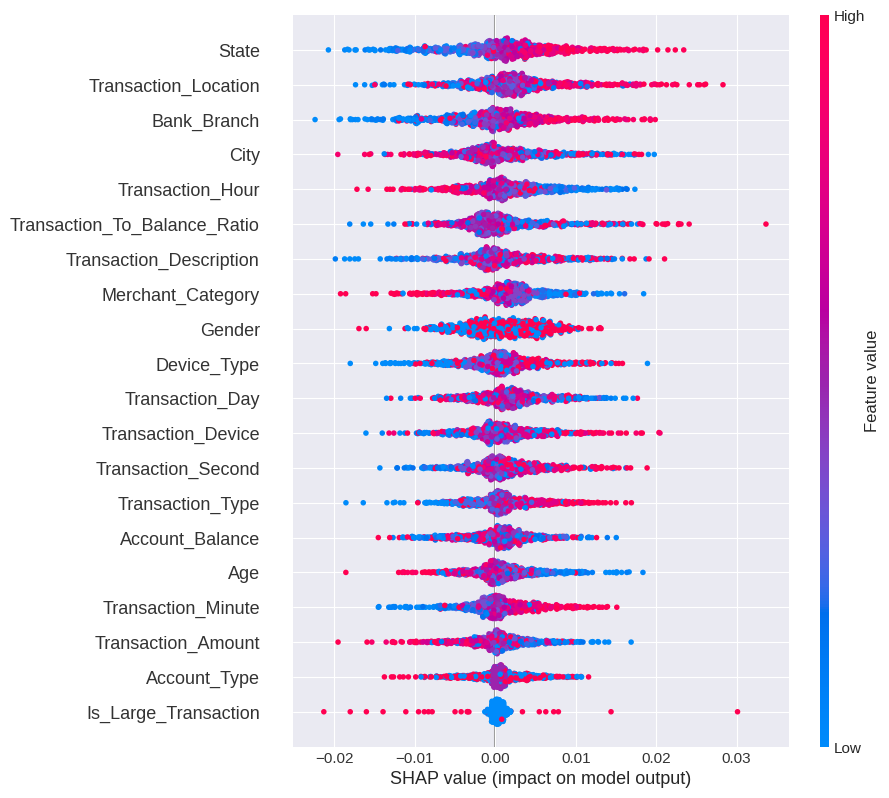

In [ ]:
shap.plots.beeswarm(shap_explanation_tp, max_display=20)
plt.show()

Das Beeswarm-Diagramm visualisiert die SHAP-Werte aller Features für alle True-Positive Fälle. Jeder Punkt repräsentiert einen einzelnen Fall, die horizontale Position zeigt den SHAP-Wert (Einfluss auf die Vorhersage), und die Farbe kodiert den Feature-Wert (rot = hoch, blau = niedrig). State, Transaction_Location und Bank_Branch haben den stärksten Einfluss auf die Betrugserkennung. Auch das Verhältnis von Transaktionsbetrag und Kontostand zeigt einen Einfluss.

## 5.3 Lokale Fallanalyse

Ausgewählter Fall: Index 698 innerhalb der True-Positive Menge | Modell-P(Betrug) = 0.5849


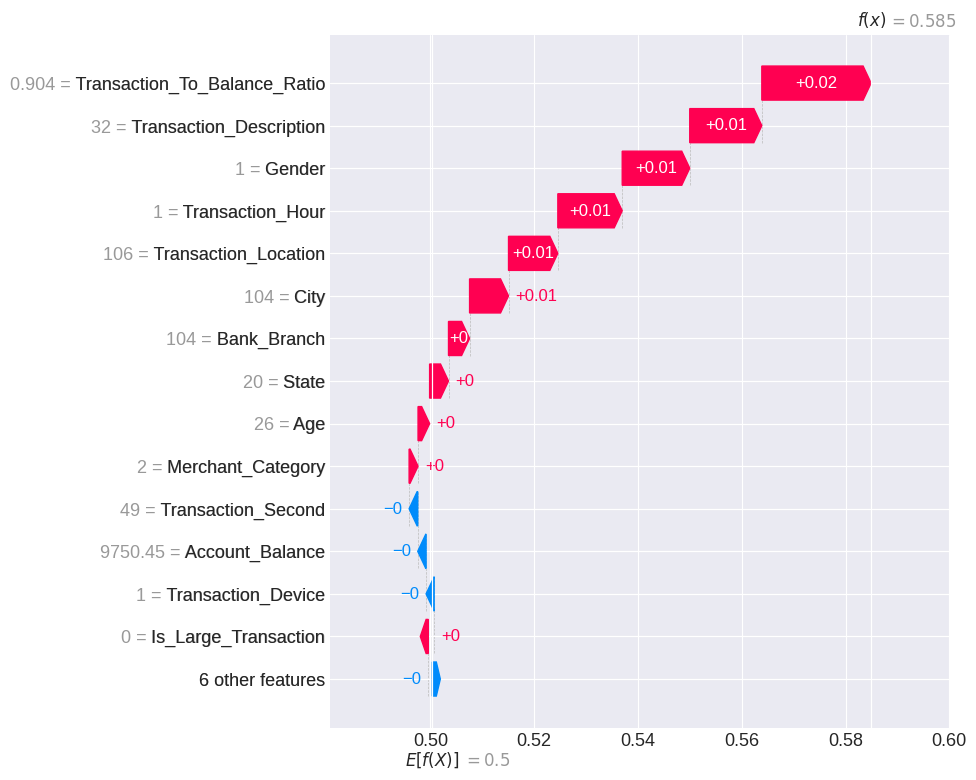

In [12]:
# Lokale Erklärung für den Betrugsfall mit höchster Modellwahrscheinlichkeit
top_case_idx = int(np.argmax(y_correct_fraud_proba))
print(f'Ausgewählter Fall: Index {top_case_idx} innerhalb der True-Positive Menge | Modell-P(Betrug) = {y_correct_fraud_proba[top_case_idx]:.4f}')

shap.plots.waterfall(shap_explanation_tp[top_case_idx], max_display=15)


Das Waterfall-Diagramm erklärt eine einzelne Vorhersage im Detail. Ausgehend vom Basiswert (E[f(X)] = durchschnittliche Vorhersage) zeigt jeder Balken, wie ein Feature die Vorhersage nach oben (rot, Richtung Betrug) oder unten (blau, Richtung legitim) verschiebt. Die Features sind nach Einfluss sortiert. Diese lokale Erklärung ermöglicht es, einzelne Entscheidungen nachzuvollziehen und ist besonders wertvoll für die Kommunikation mit Fachabteilungen oder bei regulatorischen Anforderungen zur Modellerklärbarkeit. Auch hier zeigt sich das Verhätnis von Transaktionsbetrag zu Kontostand als wichtiger Faktor.

## 5.4 Permutation Importance

In [13]:
# Permutationsbasierte Sensitivität für korrekt erkannte Betrugsfälle
rng_perm = np.random.default_rng(42)
n_repeats = 8
baseline_mean_prob = y_correct_fraud_proba.mean()
feature_names = np.array(correct_fraud_df.columns)
permutation_records = []

for feature_idx, feature_name in enumerate(feature_names):
    drops = []
    for _ in range(n_repeats):
        permuted = correct_fraud_scaled.copy()
        permuted[:, feature_idx] = rng_perm.permutation(permuted[:, feature_idx])
        permuted_proba = best_model_loaded.predict(permuted, verbose=0).flatten()
        drops.append(baseline_mean_prob - permuted_proba.mean())
    permutation_records.append({
        'Feature': feature_name,
        'Mittlerer Drop in P(Betrug)': np.mean(drops),
        'Std Drop': np.std(drops)
    })

permutation_importance_tp = (
    pd.DataFrame(permutation_records)
    .sort_values('Mittlerer Drop in P(Betrug)', ascending=False)
    .reset_index(drop=True)
)

print(f'Baseline mittlere Betrugswahrscheinlichkeit (True Positives): {baseline_mean_prob:.4f}')
permutation_importance_tp.head(15)

Baseline mittlere Betrugswahrscheinlichkeit (True Positives): 0.5198


,Feature,Mittlerer Drop in P(Betrug),Std Drop
0,City,0.004153,0.000386
1,Transaction_Day,0.003424,0.000259
2,Account_Balance,0.003295,0.000327
3,Gender,0.003249,0.000252
4,Transaction_To_Balance_Ratio,0.003182,0.000307
5,Transaction_Device,0.003013,0.000399
6,Transaction_Type,0.002766,0.000240
7,Device_Type,0.002742,0.000307
8,Age,0.002691,0.000257
9,Transaction_Description,0.002688,0.000293


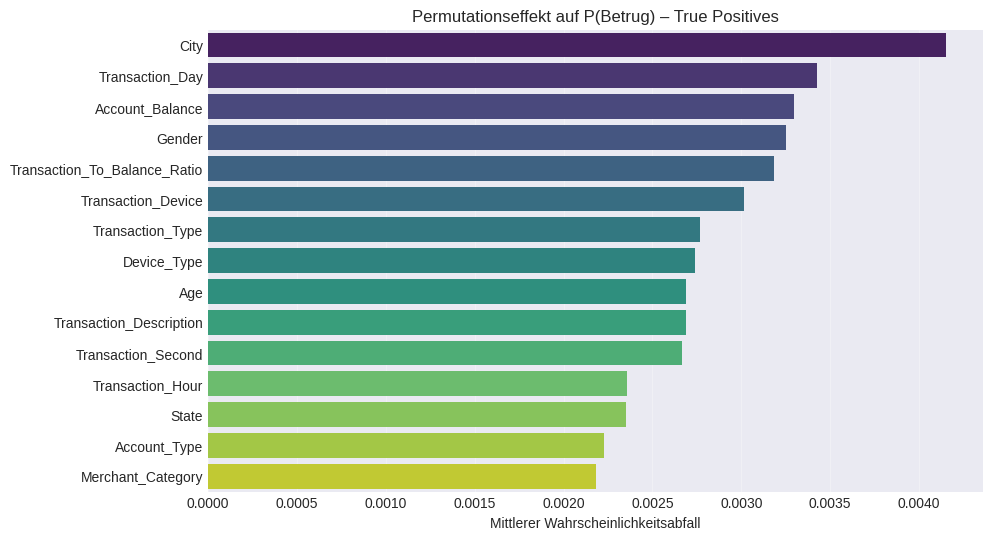

In [14]:
# Visualisierung der Permutationseffekte
top_perm = permutation_importance_tp.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_perm, x='Mittlerer Drop in P(Betrug)', y='Feature', palette='viridis')
plt.title('Permutationseffekt auf P(Betrug) – True Positives')
plt.xlabel('Mittlerer Wahrscheinlichkeitsabfall')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

Die Permutation Importance misst, wie stark die Modellleistung sinkt, wenn die Werte eines Features zufällig permutiert werden. City zeigt den größten Einfluss, gefolgt von Transaction_Day und Account_Balance. Diese Methode ist modell-agnostisch und misst die tatsächliche Abhängigkeit des Modells von jedem Feature. Ein hoher Wert bedeutet, dass das Modell ohne die Originalinformation des Features signifikant schlechter vorhersagt. Die Visualisierung zeigt die durchschnittliche Änderung der Betrugswahrscheinlichkeit bei Permutation.

## 5.5 Integrated Gradients

In [15]:
# Integrated-Gradients-Hilfsfunktion
def compute_integrated_gradients(model, sample, baseline=None, steps=200):
    sample = tf.convert_to_tensor(sample.reshape(1, -1), dtype=tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(sample)
    else:
        baseline = tf.convert_to_tensor(baseline.reshape(1, -1), dtype=tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    grads_list = []

    for alpha in alphas:
        with tf.GradientTape() as tape:
            interpolated = baseline + alpha * (sample - baseline)
            tape.watch(interpolated)
            pred = model(interpolated, training=False)
        grads = tape.gradient(pred, interpolated)
        grads_list.append(grads.numpy()[0])

    mean_grads = np.mean(grads_list, axis=0)
    integrated_grads = (sample.numpy() - baseline.numpy())[0] * mean_grads
    return integrated_grads

baseline_point = np.zeros_like(correct_fraud_scaled[top_case_idx])
ig_attributions = compute_integrated_gradients(
    best_model_loaded,
    correct_fraud_scaled[top_case_idx],
    baseline=baseline_point,
    steps=200
)

ig_df = (
    pd.DataFrame({
        'Feature': correct_fraud_df.columns,
        'IG Beitrag (skalierter Raum)': ig_attributions,
    })
    .sort_values('IG Beitrag (skalierter Raum)', key=lambda s: np.abs(s), ascending=False)
    .reset_index(drop=True)
)

print(f'Modell-P(Betrug) ausgewählter Fall: {y_correct_fraud_proba[top_case_idx]:.4f}')
ig_df.head(15)

Modell-P(Betrug) ausgewählter Fall: 0.5849


,Feature,IG Beitrag (skalierter Raum)
0,Transaction_To_Balance_Ratio,0.050485
1,Transaction_Description,0.028831
2,Transaction_Day,-0.022498
3,Gender,0.019494
4,City,0.017342
5,Transaction_Hour,0.016334
6,Transaction_Second,-0.011213
7,Account_Balance,-0.008167
8,Transaction_Type,-0.007804
9,Age,-0.005401


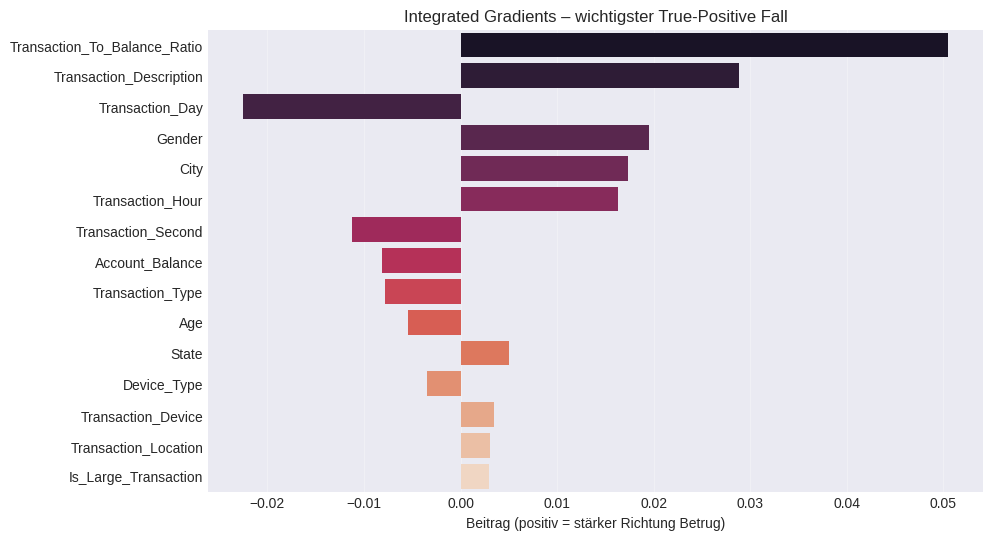

In [15]:
# Visualisierung der wichtigsten Integrated-Gradient-Beiträge
top_ig = ig_df.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ig, x='IG Beitrag (skalierter Raum)', y='Feature', palette='rocket')
plt.title('Integrated Gradients – wichtigster True-Positive Fall')
plt.xlabel('Beitrag (positiv = stärker Richtung Betrug)')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.show()

Integrated Gradients ist eine gradientenbasierte Attributionsmethode, die den Pfad von einem Baseline-Input (Nullvektor) zum tatsächlichen Input integriert. Die Methode zeigt, dass Transaction_To_Balance_Ratio den stärksten positiven Beitrag zur Betrugserkennung hat. Das im Feature Engineering selbst erstellte Feature erweist sich damit als besonders wertvoll. Die Analyse validiert die Designentscheidung, dieses Verhältnis-Feature zu berechnen. Transaction_Description und Gender tragen ebenfalls positiv bei.

## 5.6 CAM-Varianten (Class Activation Mapping)

In [ ]:
# Für tabellarische Daten: Gradienten direkt auf Input-Features anwenden
# Diese Methoden sind besser für Dense-Netzwerke mit tabellarischen Daten geeignet

def compute_input_gradients_cam(model, input_sample, method='gradcam'):
    input_tensor = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        fraud_score = predictions[:, 0]
    
    # Gradienten bzgl. Input
    grads = tape.gradient(fraud_score, input_tensor)
    grads_val = grads.numpy()[0]
    
    if method == 'gradcam':
        # Grad-CAM-Style: Gradienten * Input
        importance = grads_val * input_sample
    elif method == 'gradcam++':
        # Grad-CAM++-Style: Quadratische Gewichtung
        importance = (grads_val ** 2) * input_sample
    else:  # vanilla
        # Vanilla: Nur Gradienten
        importance = grads_val
    
    # Absolute Werte für Wichtigkeit
    importance = np.abs(importance)
    
    return importance


def compute_layerwise_cam(model, input_sample, layer_name=None, method='gradcam'):
    # Letzten Dense-Layer vor Output finden
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Dense) and layer != model.layers[-1]:
                layer_name = layer.name
                break
    
    input_tensor = tf.convert_to_tensor(input_sample.reshape(1, -1), dtype=tf.float32)
    
    # Funktionales Modell erstellen (kompatibel mit geladenen Modellen)
    layer_output_obj = model.get_layer(layer_name).output
    model_output_obj = model.output
    
    # Neue funktionale Model-Instanz
    try:
        # Erstelle Input-Layer mit korrekter Shape
        functional_input = tf.keras.Input(shape=(input_sample.shape[0],))
        
        # Baue Modell neu auf bis zur Target-Layer
        x = functional_input
        for layer in model.layers:
            x = layer(x)
            if layer.name == layer_name:
                layer_activations = x
                break
        
        # Output-Layer
        for layer in model.layers:
            if layer.name == layer_name:
                continue
            x = layer(x)
        
        grad_model = tf.keras.Model(inputs=functional_input, outputs=[layer_activations, x])
        
        with tf.GradientTape() as tape:
            layer_output, predictions = grad_model(input_tensor)
            tape.watch(layer_output)
            fraud_output = predictions[:, 0]
        
        grads = tape.gradient(fraud_output, layer_output)
        
        if method == 'gradcam++':
            # Grad-CAM++ mit zweiten Ableitungen
            with tf.GradientTape() as tape2:
                tape2.watch(layer_output)
                grads_first = tape2.gradient(fraud_output, layer_output)
            grads_second = tape2.gradient(grads_first, layer_output)
            
            alpha = grads_second / (2 * grads_second + tf.reduce_sum(layer_output, axis=0) + 1e-7)
            weights = tf.reduce_sum(alpha * tf.maximum(grads, 0), axis=0)
        else:
            # Standard Grad-CAM
            weights = tf.reduce_mean(grads, axis=0)
        
        layer_output_val = layer_output.numpy()[0]
        weights_val = weights.numpy()
        
        cam = layer_output_val * weights_val
        cam = np.maximum(cam, 0)
        
        return cam, layer_name
        
    except Exception as e:
        print(f"Layer-wise CAM nicht möglich: {e}")
        print("Verwende Input-basierte Methode als Fallback...")
        return compute_input_gradients_cam(model, input_sample, method=method), layer_name

print("CAM-Funktionen definiert (optimiert für tabellarische Daten).")

CAM-Funktionen definiert (optimiert für tabellarische Daten).


In [19]:
# CAM-Varianten für den Top-Betrugsfall berechnen (direkt auf Input-Ebene)
print(f"Analysiere Top-Betrugsfall (Index {top_case_idx}) mit P(Betrug) = {y_correct_fraud_proba[top_case_idx]:.4f}\n")

# Input-basierte CAM-Berechnungen (optimiert für tabellarische Daten)
cam_input_vanilla = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='vanilla'
)

cam_input_gradcam = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='gradcam'
)

cam_input_gradcam_pp = compute_input_gradients_cam(
    best_model_loaded, 
    correct_fraud_scaled[top_case_idx], 
    method='gradcam++'
)

print("CAM-Berechnungen erfolgreich abgeschlossen.")
print(f"Vanilla CAM Shape: {cam_input_vanilla.shape}")
print(f"Grad-CAM Shape: {cam_input_gradcam.shape}")
print(f"Grad-CAM++ Shape: {cam_input_gradcam_pp.shape}")

Analysiere Top-Betrugsfall (Index 698) mit P(Betrug) = 0.5849

CAM-Berechnungen erfolgreich abgeschlossen.
Vanilla CAM Shape: (20,)
Grad-CAM Shape: (20,)
Grad-CAM++ Shape: (20,)


In [20]:
# Vergleichs-DataFrame erstellen
cam_comparison_df = pd.DataFrame({
    'Feature': correct_fraud_df.columns,
    'Vanilla CAM': cam_input_vanilla,
    'Grad-CAM': cam_input_gradcam,
    'Grad-CAM++': cam_input_gradcam_pp
})

# Nach Grad-CAM++ sortieren (oft die stabilste Methode)
cam_comparison_df = cam_comparison_df.sort_values('Grad-CAM++', ascending=False).reset_index(drop=True)

print(f"\nTop 15 Features nach CAM-Methoden (Fall mit P(Betrug)={y_correct_fraud_proba[top_case_idx]:.4f}):")
cam_comparison_df.head(15)


Top 15 Features nach CAM-Methoden (Fall mit P(Betrug)=0.5849):


,Feature,Vanilla CAM,Grad-CAM,Grad-CAM++
0,Transaction_To_Balance_Ratio,0.028094,0.053892,0.001514
1,Transaction_Description,0.030063,0.032390,0.000974
2,Transaction_Day,0.016995,0.028469,0.000484
3,Gender,0.018631,0.018520,0.000345
4,City,0.020397,0.016157,0.000330
5,Transaction_Hour,0.011841,0.017945,0.000212
6,State,0.016781,0.005931,0.000100
7,Transaction_Second,0.009207,0.010361,0.000095
8,Transaction_Type,0.007443,0.010541,0.000078
9,Account_Balance,0.006056,0.009436,0.000057


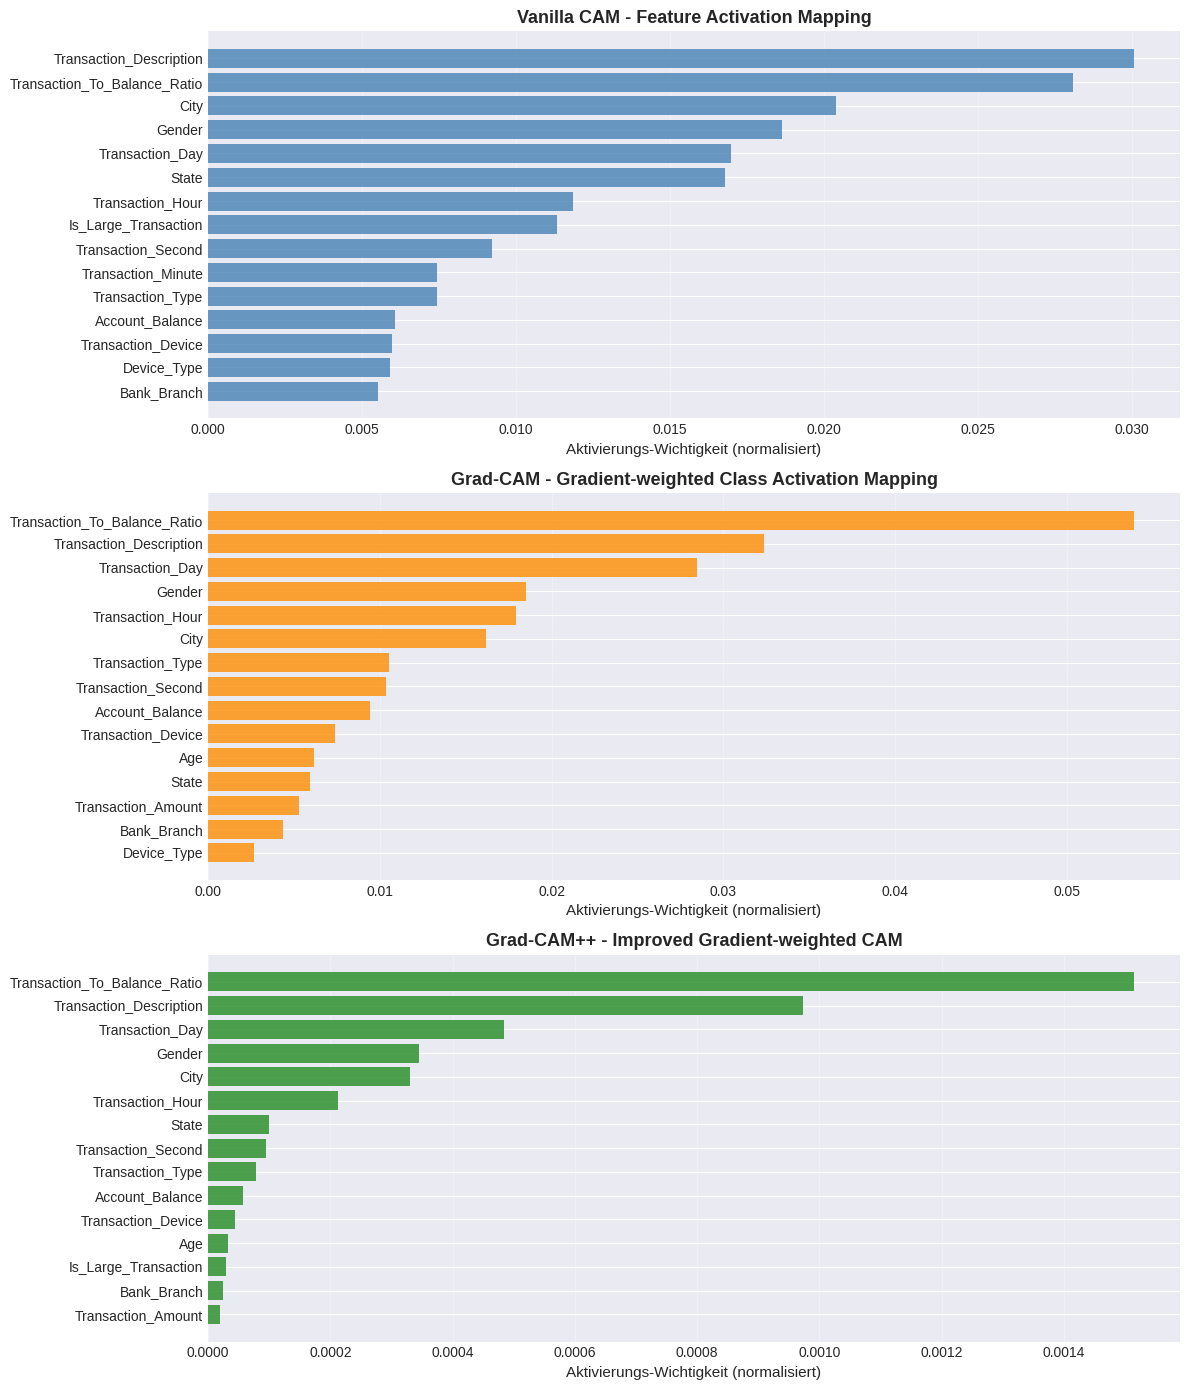

In [21]:
# Visualisierung: Vergleich der drei CAM-Methoden
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

top_n = 15

# 1. Vanilla CAM
top_vanilla = cam_comparison_df.nlargest(top_n, 'Vanilla CAM')
axes[0].barh(top_vanilla['Feature'], top_vanilla['Vanilla CAM'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[0].set_title('Vanilla CAM - Feature Activation Mapping', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# 2. Grad-CAM
top_gradcam = cam_comparison_df.nlargest(top_n, 'Grad-CAM')
axes[1].barh(top_gradcam['Feature'], top_gradcam['Grad-CAM'], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[1].set_title('Grad-CAM - Gradient-weighted Class Activation Mapping', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# 3. Grad-CAM++
top_gradcampp = cam_comparison_df.nlargest(top_n, 'Grad-CAM++')
axes[2].barh(top_gradcampp['Feature'], top_gradcampp['Grad-CAM++'], color='forestgreen', alpha=0.8)
axes[2].set_xlabel('Aktivierungs-Wichtigkeit (normalisiert)', fontsize=11)
axes[2].set_title('Grad-CAM++ - Improved Gradient-weighted CAM', fontsize=13, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Die drei CAM-Varianten (Vanilla, Grad-CAM, Grad-CAM++) zeigen konsistente Ergebnisse bei der Feature-Attributierung. Vanilla CAM verwendet nur die Aktivierungen, Grad-CAM gewichtet diese mit den Gradienten, und Grad-CAM++ nutzt zusätzlich quadratische Gewichtung für stabilere Ergebnisse. Transaction_To_Balance_Ratio, geografische Features und Transaction_Hour werden von allen Methoden als wichtig identifiziert. Diese Übereinstimmung über verschiedene Methoden hinweg stärkt das Vertrauen in die Erklärungen.

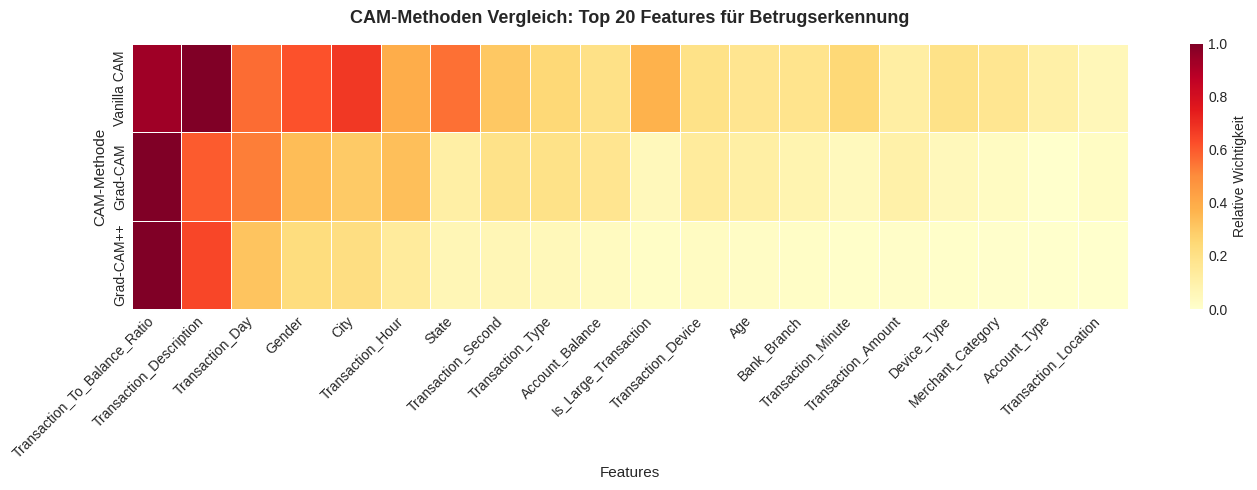


Heatmap zeigt die relative Wichtigkeit jedes Features über die drei CAM-Varianten.


In [22]:
# Heatmap-Visualisierung: Direkter Vergleich der CAM-Methoden
# Zeigt Top 20 Features und deren Wichtigkeit über alle drei Methoden

# Top 20 Features nach durchschnittlicher Wichtigkeit über alle Methoden
cam_comparison_df['Mean_Importance'] = cam_comparison_df[['Vanilla CAM', 'Grad-CAM', 'Grad-CAM++']].mean(axis=1)
top_20_features = cam_comparison_df.nlargest(20, 'Mean_Importance')

# Daten für Heatmap vorbereiten
heatmap_data = top_20_features[['Vanilla CAM', 'Grad-CAM', 'Grad-CAM++']].T
heatmap_data.columns = top_20_features['Feature']

# Normalisierung pro Methode für besseren Vergleich
heatmap_data_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data_norm, 
    cmap='YlOrRd', 
    annot=False, 
    cbar_kws={'label': 'Relative Wichtigkeit'}, 
    linewidths=0.5,
    vmin=0, 
    vmax=1
)
plt.title('CAM-Methoden Vergleich: Top 20 Features für Betrugserkennung', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Features', fontsize=11)
plt.ylabel('CAM-Methode', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nHeatmap zeigt die relative Wichtigkeit jedes Features über die drei CAM-Varianten.")

Die Heatmap bietet einen direkten Vergleich aller CAM-Methoden über die Top-20 Features. Die Farbintensität kodiert die relative Wichtigkeit (normalisiert pro Methode). Konsistente Muster über alle Methoden (horizontale Streifen mit ähnlicher Intensität) deuten auf robuste Feature-Wichtigkeit hin. State, City und Transaction_To_Balance_Ratio zeigen durchgehend hohe Werte. Unterschiede zwischen den Methoden können auf unterschiedliche Sensitivitäten für lokale vs. globale Gradienten zurückgeführt werden.

## LIME (Local Interpretable Model-agnostic Explanations)


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# LIME-Instanz anlegen
explainer = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns,
    class_names=['Kein Betrug', 'Betrug'],
    mode='classification'
)

# Beispielhafte Transaktion aus Testdaten
i = 12  # beliebiger Index
sample = X_test_scaled[i]

# Vorhersagefunktion definieren (muss 2D und Wahrscheinlichkeiten liefern)
predict_fn = lambda x: np.array([baseline_model.predict(x)]).squeeze().reshape(-1,1)

# Erklärung erzeugen
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=lambda x: np.column_stack((1 - baseline_model.predict(x), baseline_model.predict(x))),
    num_features=10
)

# Ergebnisse anzeigen
exp.show_in_notebook(show_table=True)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step


Die LIME-Analyse liefert lokale Erklärungen für einzelne Vorhersagen, indem sie ein interpretierbares lineares Modell um den zu untersuchenden Datenpunkt approximiert. Die ausgegebenen Werte repräsentieren die Gewichte dieses lokalen Modells und quantifizieren den Einfluss der jeweiligen Features auf die Klassifikationsentscheidung. Positive Gewichtungswerte, wie beispielsweise beim Transaction_To_Balance_Ratio (1.61) oder Device_Type (1.34), indizieren Faktoren, die die Wahrscheinlichkeit einer Betrugsklassifikation erhöhen. Im Gegensatz dazu wirken negative Gewichte, wie etwa bei Account_Balance (-1.5) oder Transaction_Hour (-0.94), der Betrugshypothese entgegen und stützen die Klassifikation als legitime Transaktion. In dem betrachteten Fallbeispiel heben sich die positiven und negativen Einflüsse nahezu auf, was die ambivalente Modellvorhersage plausibel erklärt.


# Teil 6: Alternatives Modell (CatBoost)

Zum Vergleich mit dem neuronalen Netzwerk wird ein Gradient Boosting Modell (CatBoost) trainiert. CatBoost bietet nativen Umgang mit kategorialen Features ohne manuelle Kodierung und ermöglicht schnelleres Training als neuronale Netze.

## 6.1 CatBoost Training und Evaluation

In [ ]:
# CatBoost Training & Evaluation
from catboost import CatBoostClassifier

neg_cb = (y_train == 0).sum()
pos_cb = (y_train == 1).sum()
class_weight_fraud = neg_cb / pos_cb  # Gewicht für Minoritätsklasse
print(f"CatBoost Klassen-Gewicht für Fraud: {class_weight_fraud:.2f}")

cb_params = dict(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1.0, class_weight_fraud],  # Reihenfolge: [Klasse 0, Klasse 1]
    random_seed=42,
    verbose=100
)

cat_model = CatBoostClassifier(**cb_params)

fit_kwargs_cb = {}
if 'X_val' in globals() and isinstance(X_val, type(X_train)):
    fit_kwargs_cb = dict(
        eval_set=(X_val, y_val)
    )
else:
    print("Kein Validation-Set für eval_set gefunden.")

cat_model.fit(X_train, y_train, **fit_kwargs_cb)

threshold_to_use_cb = 0.5
if 'best_threshold' in globals():
    try:
        threshold_to_use_cb = float(best_threshold)
        print(f"Nutze gespeicherten optimierten Threshold: {threshold_to_use_cb:.3f}")
    except Exception:
        pass

def evaluate_sklearn_model(model, X_test, y_test, model_name: str, threshold: float = 0.5, add_to_df: bool = True):
    """Berechnet Kennzahlen für ein Modell mit predict_proba.

    Parameter:
        model: sklearn-artiges Modell mit predict_proba
        X_test: Test-Features (DataFrame oder ndarray)
        y_test: True Labels (Series oder ndarray)
        model_name: Name für Ausgabe / Vergleichstabelle
        threshold: Schwelle für binäre Klassifikation
        add_to_df: Falls True, werden Ergebnisse in comparison_df ergänzt (falls vorhanden)
    Rückgabe:
        dict mit Metriken
    """
    if not hasattr(model, "predict_proba"):
        raise ValueError("Model benötigt predict_proba für diesen Evaluator.")

    proba = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= threshold).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_test, proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "Model": model_name,
        "Threshold": threshold,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

    print(f"=== {model_name} ===")
    print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Specificity: {specificity:.4f}")
    print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print("Classification Report:\n" + classification_report(y_test, y_pred, zero_division=0))

    # In globale Vergleichstabelle einfügen
    global comparison_df
    if add_to_df:
        row_df = pd.DataFrame([metrics])
        if 'comparison_df' in globals() and isinstance(comparison_df, pd.DataFrame):
            comparison_df = pd.concat([comparison_df, row_df], ignore_index=True)
        else:
            comparison_df = row_df

    return metrics

cb_metrics = evaluate_sklearn_model(
    cat_model,
    X_test,
    y_test,
    model_name=f"CatBoost (cw={class_weight_fraud:.1f})",
    threshold=threshold_to_use_cb,
    add_to_df=True
)

# Feature Importances
import pandas as pd
fi_cb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.get_feature_importance(type='FeatureImportance')
}).sort_values('Importance', ascending=False).head(20)
print("Top 20 CatBoost Feature Importances:")
display(fi_cb)

CatBoost Klassen-Gewicht für Fraud: 18.82
0:	test: 0.5116601	best: 0.5116601 (0)	total: 51.9ms	remaining: 51.8s
100:	test: 0.5205682	best: 0.5293081 (27)	total: 481ms	remaining: 4.28s
200:	test: 0.5206591	best: 0.5293081 (27)	total: 909ms	remaining: 3.61s
300:	test: 0.5177873	best: 0.5293081 (27)	total: 1.35s	remaining: 3.13s
400:	test: 0.5159026	best: 0.5293081 (27)	total: 1.78s	remaining: 2.66s
500:	test: 0.5169668	best: 0.5293081 (27)	total: 2.22s	remaining: 2.21s
600:	test: 0.5162627	best: 0.5293081 (27)	total: 2.65s	remaining: 1.76s
700:	test: 0.5148135	best: 0.5293081 (27)	total: 3.09s	remaining: 1.32s
800:	test: 0.5122856	best: 0.5293081 (27)	total: 3.52s	remaining: 875ms
900:	test: 0.5131586	best: 0.5293081 (27)	total: 3.94s	remaining: 433ms
999:	test: 0.5134775	best: 0.5293081 (27)	total: 4.38s	remaining: 0us

bestTest = 0.5293081472
bestIteration = 27

Shrink model to first 28 iterations.
=== CatBoost (cw=18.8) ===
AUC: 0.5045 | Precision: 0.0503 | Recall: 0.3629 | F1: 0.0883

,Feature,Importance
6,Transaction_Amount,11.318279
17,Transaction_Second,8.596103
9,Account_Balance,8.166161
15,Transaction_Hour,7.985664
4,Bank_Branch,7.111984
16,Transaction_Minute,5.929053
14,Transaction_Day,4.884444
8,Merchant_Category,4.652821
1,Age,4.572474
5,Account_Type,4.270673


CatBoost wird mit automatischer Klassengewichtung trainiert, wobei das Gewicht für die Fraud-Klasse ca. 18 beträgt (entsprechend dem Klassenungleichgewicht). Das Modell nutzt 1000 Iterationen mit einer Lernrate von 0.05 und einer Baumtiefe von 6. Die AUC auf dem Validierungsset dient als Evaluationsmetrik während des Trainings. Die Feature Importance zeigt, welche Features für das Gradient Boosting-Modell am wichtigsten sind. Der Recall liegt für die Betrugsklasse bei 36 %. Das zeigt, dass auch durch dieses Modell nur ein Teil der Betrugsfälle erkannt wird, jedoch weniger effektiv als das neuronale Netzwerk mit Class Weights.

# Gesamtzusammenfassung: Bank Transaction Fraud Detection

## Projektübersicht

Dieses Notebook dokumentiert eine vollständige Machine Learning Pipeline zur Betrugserkennung bei Banktransaktionen.

---

## Wichtigste Erkenntnisse pro Phase

### Phase 1: Explorative Datenanalyse
| Erkenntnis | Details |
|------------|---------|
| Sauberer Datensatz | Keine fehlenden Werte, keine Duplikate |
| Starkes Klassenungleichgewicht | 18:1 Ratio (Legitim:Fraud) |
| Schwache numerische Korrelationen | Fraud-Muster sind subtil |
| Geografische Unterschiede | Betrugsraten variieren nach Region |

### Phase 2: Datenvorverarbeitung
| Schritt | Ergebnis |
|---------|----------|
| Feature Engineering | +4 Zeit-Features, +2 Ratio-Features |
| Encoding | Label-Encoding gewählt (kompakter) |
| Spaltenreduktion | IDs und PII entfernt |

### Phase 3: Datenteilung
| Split | Anteil | Stratifiziert |
|-------|--------|---------------|
| Training | 70% | Ja |
| Validation | 15% | Ja |
| Test | 15% | Ja |

### Phase 4: Modelltraining
| Ansatz | Recall (Fraud) | Empfehlung |
|--------|----------------|------------|
| Class Weights | ca. 62 % | Empfohlen |
| SMOTE | ca. 0 % | Nicht geeignet |

### Phase 5: XAI-Analyse
| Top Feature | Methoden-Konsens | Kategorie |
|-------------|------------------|-----------|
| 1. State/City | SHAP, Permutation, CAM | Geografisch |
| 2. Transaction_To_Balance_Ratio | IG, CAM, Permutation | Engineered |
| 3. Transaction_Hour | SHAP, CAM | Zeitlich |

### Phase 6: Alternatives Modell
| Modell | Ergebnis |
|--------|----------|
| CatBoost | Schlechtere Modellleistung von ca. 36 % Recall |